In [1]:
import os
import vr2p
import zarr
import math
import pickle
import warnings
import vr2p.signal
import numpy as np
import pandas as pd
import colorcet as cc
import seaborn as sns
from tqdm import tqdm
from vr2p import styles
from scipy import stats
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt 
from scipy.stats import rankdata
from matplotlib import cm, colors
mpl.rcParams['pdf.fonttype'] = 42
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from ipyfilechooser import FileChooser
from skimage.measure import regionprops
from sklearn.impute import SimpleImputer
from linear2ac.io import get_main_data_folder
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from sklearn.decomposition import NMF
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.manifold import MDS
from scipy.stats import linregress
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
from scipy.stats import wilcoxon
from scipy.stats import sem, kruskal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode
from sklearn.naive_bayes import GaussianNB
from scipy.ndimage import zoom
from scipy.ndimage import generic_filter
from sklearn.manifold import MDS
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#### Functions

In [6]:
def load_animal_spatial_data_trial_by_trial(animal_name, base_path="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Set A", bin_size=5, min_speed=5, track_size=230):

    data = vr2p.ExperimentData(f"{base_path}/{animal_name}-SetA.zarr/")
    edges = np.arange(0, track_size + bin_size, bin_size)
    n_bins = len(edges) - 1

    results = {"fields": [], "speed": [], "trial_types": [], "trial_numbers": [], "day_ind": []}

    for s, vr in enumerate(data.vr):
        print(f"On Session {s}")

        trial = vr.trial.copy()
        pos = vr.path.frame.copy().reset_index().merge(trial[["trial_number", "reward_id"]], on="trial_number")
        pos["speed"] = pos.vr2p.rolling_speed(window_size=100, ignore_threshold=7.5)

        F = data.signals.multi_session.Fdemix[int(s)][:]
        F = F - F.min(axis=1, keepdims=True)
        dff, _ = vr2p.signal.df_over_f0(F, "maximin", subtract_min=True, sigma_baseline=20, window_size=200)

        p = pos.loc[pos.speed >= min_speed, ["frame", "position", "trial_number", "reward_id", "speed"]].copy()

        valid = [t for t in trial.trial_number.values if len(p[p.trial_number == t]) and np.nanmax(p[p.trial_number == t].position) >= 226]

        if not valid:
            continue

        p = p[p.trial_number.isin(valid)].copy()
        p["trial_idx"] = p.trial_number.map({t: i for i, t in enumerate(valid)})
        p["bin"] = pd.cut(p.position, edges, include_lowest=True, labels=False)
        p = p.dropna(subset=["bin"]).copy()
        p["bin"] = p["bin"].astype(int)
        p = p[p.bin >= 0]

        mat = np.full((len(valid), F.shape[0], n_bins), np.nan)
        speed = np.full((len(valid), n_bins), np.nan)

        for (ti, bi), g in p.groupby(["trial_idx", "bin"]):
            frames = g.frame.to_numpy()
            mat[ti, :, bi] = dff[:, frames].mean(axis=1)
            speed[ti, bi] = g.speed.mean()

        results["fields"].append(mat)  # n_trials x n_cells x n_bins
        results["speed"].append(speed) # n_trials x n_bins
        results["trial_types"].append(trial.set_index("trial_number").loc[valid, "reward_id"].to_numpy())
        results["trial_numbers"].append(np.asarray(valid))
        results["day_ind"].append(s)

    return results

def load_animal_continuous_data(
        animal_name, 
        session, 
        base_path="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Set A", 
        min_speed=0, 
        track_size=230):
    data = vr2p.ExperimentData(f"{base_path}/{animal_name}-SetA.zarr/")

    vr = data.vr[session]
    print(f"On Session {session}")

    # behavior
    trial = vr.trial.copy()

    pos = (vr.path.frame.copy().reset_index().merge(trial[["trial_number", "reward_id"]], on="trial_number"))
    pos["speed"] = pos.vr2p.rolling_speed(window_size=100, ignore_threshold=7.5)

    # neural data
    #F = data.signals.multi_session.Fdemix[int(session)][:]
    #F = F - F.min(axis=1, keepdims=True)

    #dff, _ = vr2p.signal.df_over_f0(F, "maximin", subtract_min=True, sigma_baseline=20, window_size=200)

    # deconvolved traces
    F_dcs = data.signals.multi_session.spks[int(session)][:]

    n_neurons, T = F_dcs.shape

    # valid frames
    p = pos.loc[pos.speed >= min_speed, ["frame", "position", "trial_number", "reward_id", "speed"]].copy()

    valid_trials = [t for t in trial.trial_number.values if len(p[p.trial_number == t]) and np.nanmax(p[p.trial_number == t].position) >= track_size - 4]

    if not valid_trials:
        return None

    p = p[p.trial_number.isin(valid_trials)].copy()
    p = p[(p.frame >= 0) & (p.frame < T)].copy()

    if len(p) == 0:
        return None

    # time from trial onset
    p["time_from_trial_onset"] = (p.groupby("trial_number")["frame"].transform(lambda x: x - x.min()))

    frames = p["frame"].to_numpy().astype(int)

    # lick data
    lick = vr.lick.copy()
    lick = lick[(lick.frame >= 0) & (lick.frame < T) & (lick.period == "TASK")]

    lick_frames = lick["frame"].to_numpy().astype(int)

    lick_binary_full = np.zeros(T)
    lick_binary_full[lick_frames] = 1

    lick_count_full = np.zeros(T)
    np.add.at(lick_count_full, lick_frames, 1)

    # -------- final output (no lists) --------
    results = {
        #"F": F[:, frames],
        #"dff": dff[:, frames],
        "F_dcs": F_dcs[:, frames],
        "position": p["position"].to_numpy(),
        "speed": p["speed"].to_numpy(),
        "time_from_trial_onset": p["time_from_trial_onset"].to_numpy(),
        "trial_type": p["reward_id"].to_numpy(),
        "trial_number": p["trial_number"].to_numpy(),
        "frame": frames,
        "day_ind": np.full(len(frames), session),
        "lick_binary": lick_binary_full[frames],
        "lick_count": lick_count_full[frames]}

    return results

def fill_nan_local_mean(mat, size=3):

    def nanmean_filter(x):
        x = x[np.isfinite(x)]
        return np.mean(x) if len(x) else np.nan

    mask = np.isnan(mat)
    filled = generic_filter(mat, nanmean_filter, size=size, mode="nearest")

    out = mat.copy()
    out[mask] = filled[mask]

    return out

def load_animal_spatial_data_session_by_session(animal, criteria="putative",
    base_setA="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Set A",
    base_pf="/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/placeFields"):
    
    # --- load experiment data ---
    path = f"{base_setA}/{animal}-SetA.zarr/"
    data = vr2p.ExperimentData(path)

    # --- find consecutive days with Cue Set A only ---
    day_count = []
    for i in range(len(data.signals.multi_session.F)):
        sets = data.vr[i].trial.set.unique()
        if ("Cue Set A" in sets) and (len(sets) == 1):
            day_count.append(i)
        else:
            break

    max_day = int(max(day_count))  # last valid day index
    range_A = range(max_day + 1)

    # --- open PF zarr ---
    zarr_path = f"{base_pf}/{animal}-SetA.zarr-PF.zarr"
    zf = zarr.open(zarr_path, mode="r")

    # --- load PF analysis per day ---
    pf_all_T1 = [zf[f"Cue Set A/1/excl_no_response/{i}/{criteria}"][()] for i in range_A]
    pf_all_T2 = [zf[f"Cue Set A/2/excl_no_response/{i}/{criteria}"][()] for i in range_A]

    # --- load binned tuning curves per day ---
    binF_T1 = [pf_all_T1[i]["binF"] for i in range(len(pf_all_T1))]
    binF_T2 = [pf_all_T2[i]["binF"] for i in range(len(pf_all_T2))]

    binF_T1_all = np.array(binF_T1).T  # (N_cells, N_bins, N_sessions) depending on binF shape
    binF_T2_all = np.array(binF_T2).T

    return {
        "animal": animal,
        "path": path,
        "max_day": max_day,
        "range_A": range_A,
        "pf_all_T1": pf_all_T1,
        "pf_all_T2": pf_all_T2,
        "binF_T1_all": binF_T1_all,
        "binF_T2_all": binF_T2_all,
    }

def safe_nanmean(a, axis):
    count = np.sum(~np.isnan(a), axis=axis)
    total = np.nansum(a, axis=axis)

    out = np.full(total.shape, np.nan)
    mask = count > 0
    out[mask] = total[mask] / count[mask]

    return out

def build_trial_bin_population_matrix(
        PF,
        trial_types,
        trial_numbers,
        input_bin_size=5,
        output_bin_size=10,
        trial_block_size=3):
    """
    PF: n_trials x n_cells x n_bins

    trial_block_size:
        number of trials to average together.
        Trials are blocked separately within each trial type.

    returns:
        X:    (n_trial_blocks * n_output_bins) x n_cells
        meta: dataframe
    """

    n_trials, n_cells, n_bins_in = PF.shape

    trial_types = np.asarray(trial_types)
    trial_numbers = np.asarray(trial_numbers)

    if output_bin_size % input_bin_size != 0:
        raise ValueError("output_bin_size must be multiple of input_bin_size")

    combine = int(output_bin_size / input_bin_size)

    if n_bins_in % combine != 0:
        raise ValueError("n_bins not divisible by combine factor")

    if trial_block_size < 1:
        raise ValueError("trial_block_size must be >= 1")

    n_bins_out = n_bins_in // combine

    # spatial binning: trials x cells x output_bins
    PF_out = PF.reshape(n_trials, n_cells, n_bins_out, combine)
    PF_out = safe_nanmean(PF_out, axis=3)

    X_list = []
    meta = []

    block_counter = 0

    # block trials separately for each trial type
    for tt in np.unique(trial_types):

        trial_idx = np.where(trial_types == tt)[0]

        # keep original trial order
        trial_idx = trial_idx[np.argsort(trial_numbers[trial_idx])]

        for start in range(0, len(trial_idx), trial_block_size):

            block_trial_idx = trial_idx[start:start + trial_block_size]

            # average PF across trials within this block
            # shape: cells x bins
            PF_block = safe_nanmean(PF_out[block_trial_idx], axis=0)

            for b in range(n_bins_out):

                pop_vec = PF_block[:, b]

                X_list.append(pop_vec)

                meta.append({
                    "block_index": block_counter,
                    "trial_type": tt,
                    "trial_indices": block_trial_idx.tolist(),
                    "trial_numbers": trial_numbers[block_trial_idx].tolist(),
                    "block_start_trial": trial_numbers[block_trial_idx[0]],
                    "block_end_trial": trial_numbers[block_trial_idx[-1]],
                    "n_trials_in_block": len(block_trial_idx),
                    "bin": b,
                    "bin_start_cm": b * output_bin_size,
                    "bin_end_cm": (b + 1) * output_bin_size})

            block_counter += 1

    X = np.asarray(X_list)
    meta = pd.DataFrame(meta)

    return X, meta

def plot_embedding_3d_grid(
    embedding,
    Y,
    title="Embedding",
    n_plot=50000,
    position_range=None,
    normalize_embedding=True,
    marker_size=2.8,
    opacity=0.75,
):
    """
    2 x 3 interactive 3D grid.

    Row 1: trial type 1
        colored by scaled trial number, session, position

    Row 2: trial type 2
        colored by scaled trial number, session, position

    Y columns:
        0 = trial_type
        1 = trial_number
        2 = day_ind/session
        3 = position
        4 = spatial_bin
    """

    Z = np.asarray(embedding)
    Y = np.asarray(Y)

    # -------------------------------
    # base mask
    # -------------------------------

    mask = np.ones(len(Y), dtype=bool)

    sessions = np.sort(np.unique(Y[:, 2]))
    keep_sessions = sessions[:]
    mask &= np.isin(Y[:, 2], keep_sessions)

    # keep position range
    if position_range is not None:
        pmin, pmax = position_range
        mask &= (Y[:, 3] > pmin) & (Y[:, 3] < pmax)

    Z = Z[mask]
    Y = Y[mask]

    # -------------------------------
    # subsample
    # -------------------------------

    if len(Z) > n_plot:
        idx = np.random.choice(len(Z), size=n_plot, replace=False)
        Z = Z[idx]
        Y = Y[idx]

    # -------------------------------
    # normalize embedding
    # -------------------------------

    if normalize_embedding:
        Z = (Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-8)

    # -------------------------------
    # scaled trial number
    # within session x trial type
    # -------------------------------

    trial_scaled = np.full(len(Y), np.nan)

    for sess in np.unique(Y[:, 2]):
        for tt in np.unique(Y[:, 0]):

            m = (Y[:, 2] == sess) & (Y[:, 0] == tt)

            if np.sum(m) == 0:
                continue

            vals = Y[m, 1]

            trial_scaled[m] = (
                vals - vals.min()
            ) / (
                vals.max() - vals.min() + 1e-8
            )

    # -------------------------------
    # masks for trial types
    # -------------------------------

    mask_t1 = Y[:, 0] == 1
    mask_t2 = Y[:, 0] == 2

    # -------------------------------
    # figure
    # -------------------------------

    titles = [
        "T1: scaled trial number",
        "T1: session",
        "T1: position",
        "T2: scaled trial number",
        "T2: session",
        "T2: position",
    ]

    fig = make_subplots(
        rows=2,
        cols=3,
        specs=[
            [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
            [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
        ],
        subplot_titles=titles,
        horizontal_spacing=0.02,
        vertical_spacing=0.05,
    )

    def add_panel(mask_panel, color_values, row, col, colorscale, color_title):

        fig.add_trace(
            go.Scatter3d(
                x=Z[mask_panel, 0],
                y=Z[mask_panel, 1],
                z=Z[mask_panel, 2],
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_values[mask_panel],
                    colorscale=colorscale,
                    opacity=opacity,
                    colorbar=dict(
                        title=color_title,
                        len=0.32,
                    ),
                ),
                customdata=np.column_stack([
                    Y[mask_panel, 0],
                    Y[mask_panel, 1],
                    Y[mask_panel, 2],
                    Y[mask_panel, 3],
                    Y[mask_panel, 4],
                ]),
                hovertemplate=(
                    "trial type=%{customdata[0]}<br>"
                    "trial=%{customdata[1]}<br>"
                    "session=%{customdata[2]}<br>"
                    "position=%{customdata[3]:.1f} cm<br>"
                    "bin=%{customdata[4]}<br>"
                    "<extra></extra>"
                ),
                showlegend=False,
            ),
            row=row,
            col=col,
        )

    # -------------------------------
    # row 1: trial type 1
    # -------------------------------

    add_panel(mask_t1, trial_scaled, 1, 1, "Jet", "trial")
    add_panel(mask_t1, Y[:, 2],       1, 2, "Viridis", "session")
    add_panel(mask_t1, Y[:, 3],       1, 3, "HSV", "position")

    # -------------------------------
    # row 2: trial type 2
    # -------------------------------

    add_panel(mask_t2, trial_scaled, 2, 1, "Jet", "trial")
    add_panel(mask_t2, Y[:, 2],       2, 2, "Viridis", "session")
    add_panel(mask_t2, Y[:, 3],       2, 3, "HSV", "position")

    # -------------------------------
    # layout
    # -------------------------------

    fig.update_layout(
        width=1600,
        height=900,
        title=title,
        margin=dict(l=0, r=0, b=0, t=50),
    )

    fig.show()
    
def build_trial_bin_PV_single_trials(
    PF,
    trial_types,
    trial_numbers,
    session,
    bin_size=5):
    """
    PF: trials x cells x bins

    Returns:
        X:    (trials * bins) x cells
        meta: dataframe with trial/bin/session info
    """

    PF = np.asarray(PF, float)
    trial_types = np.asarray(trial_types)
    trial_numbers = np.asarray(trial_numbers)

    n_trials, n_cells, n_bins = PF.shape

    X_list = []
    meta = []

    for tr in range(n_trials):
        for b in range(n_bins):

            X_list.append(PF[tr, :, b])

            meta.append({
                "session": session,
                "trial_index": tr,
                "trial_number": trial_numbers[tr],
                "trial_type": trial_types[tr],
                "bin": b,
                "bin_1based": b + 1,
                "bin_start_cm": b * bin_size,
                "bin_end_cm": (b + 1) * bin_size})

    return np.asarray(X_list), pd.DataFrame(meta)

def corr_template_blocks_fast(
    animal_data,
    trial_type=1,
    block_size=5,
    template_cm=(130,150),
    template_session=0,
    template_block=0,
    bin_size=5
):

    blocks = []

    for s, (PF, TT) in enumerate(zip(animal_data["fields"], animal_data["trial_types"])):

        TT = np.asarray(TT)
        PF = PF[TT == trial_type]

        for b in range(len(PF) // block_size):

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)

                PF_block = np.nanmean(
                    PF[b*block_size:(b+1)*block_size],
                    axis=0
                )  # cells x bins

            blocks.append((s, b, PF_block))

    if len(blocks) < 2:
        return None

    template_bins = (
        int(template_cm[0] / bin_size),
        int(template_cm[1] / bin_size)
    )

    template_block_data = [
        blk for s, b, blk in blocks
        if s == template_session and b == template_block
    ]

    if len(template_block_data) == 0:
        return None

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)

        template = np.nanmean(
            template_block_data[0][:, template_bins[0]:template_bins[1]],
            axis=1
        )

    mat, meta = [], []

    for s, b, PF in blocks:

        r = np.full(PF.shape[1], np.nan)

        for xbin in range(PF.shape[1]):

            y = PF[:, xbin]

            m = np.isfinite(template) & np.isfinite(y)

            if (
                m.sum() > 5
                and np.std(template[m]) > 0
                and np.std(y[m]) > 0
            ):
                r[xbin] = np.corrcoef(template[m], y[m])[0, 1]

        mat.append(r)
        meta.append((s, b))

    return np.asarray(mat), meta

def detect_pf_emergence_norm01_v2(
    PFs,
    bin_size=5,
    active_thresh=0.15,
    min_consecutive_on=5,
    min_consecutive_off=4,
    in_out_ratio_thresh=2.0,
    field_radius_bins=4,
    field_activity_radius_bins=6,
    eps=1e-9,
):
    """
    PFs: trials x cells x bins

    Logic:
    1. Normalize each cell's full trial x bin matrix to [0, 1].
    2. Detect mean place-field peak.
    3. Use peak +/- field_activity_radius_bins to define the field window.
    4. A trial is active only if activity inside this field window > active_thresh.
    5. Find all active epochs.
    6. Keep the longest active epoch.
    """

    n_trials, n_cells, n_bins = PFs.shape

    emergence_trial = np.full(n_cells, np.nan)
    turnoff_trial = np.full(n_cells, np.nan)
    peak_bin = np.full(n_cells, np.nan)
    peak_cm = np.full(n_cells, np.nan)
    valid_field = np.zeros(n_cells, dtype=bool)

    PFs_norm = np.full_like(PFs, np.nan, dtype=float)

    for cell in range(n_cells):

        mat = np.asarray(PFs[:, cell, :], float)

        if np.all(~np.isfinite(mat)):
            continue

        mn = np.nanmin(mat)
        mx = np.nanmax(mat)

        if not np.isfinite(mn) or not np.isfinite(mx) or (mx - mn) < eps:
            continue

        mat_norm = (mat - mn) / (mx - mn)
        PFs_norm[:, cell, :] = mat_norm

        # ----------------------------------------------------
        # mean PF and peak detection
        # ----------------------------------------------------

        mean_curve = np.nanmean(mat_norm, axis=0)

        if np.all(~np.isfinite(mean_curve)):
            continue

        pk = int(np.nanargmax(mean_curve))

        # window for in/out place-field ratio
        left_ratio = max(0, pk - field_radius_bins)
        right_ratio = min(n_bins - 1, pk + field_radius_bins)

        in_field = mean_curve[left_ratio:right_ratio + 1]
        out_field = np.concatenate([mean_curve[:left_ratio], mean_curve[right_ratio + 1:]])

        in_mean = np.nanmean(in_field)
        out_mean = np.nanmean(out_field)

        if not np.isfinite(in_mean):
            continue

        if not np.isfinite(out_mean) or out_mean <= 0:
            continue

        if (in_mean / out_mean) < in_out_ratio_thresh:
            continue

        # window used for emergence / turnoff detection

        left_act = max(0, pk - field_activity_radius_bins)
        right_act = min(n_bins - 1, pk + field_activity_radius_bins)
        field_activity = np.nanmax(mat_norm[:, left_act:right_act + 1], axis=1)

        high = field_activity > active_thresh

        # find all active epochs with turnoff tolerance
        epochs = []
        t = 0

        while t < n_trials:

            # find start of active run
            if not high[t]:
                t += 1
                continue

            start = t

            # require min_consecutive_on active trials at the beginning
            count_on = 0
            while t < n_trials and high[t]:
                count_on += 1
                t += 1

                if count_on >= min_consecutive_on:
                    break

            if count_on < min_consecutive_on:
                continue

            # true emergence is first trial of this active segment
            epoch_start = start

            # now continue until min_consecutive_off inactive trials
            off_count = 0
            last_active = t - 1

            while t < n_trials:

                if high[t]:
                    off_count = 0
                    last_active = t
                else:
                    off_count += 1

                if off_count >= min_consecutive_off:
                    break

                t += 1

            epoch_end = last_active

            epochs.append((epoch_start, epoch_end))

            t += 1

        if len(epochs) == 0:
            continue

        # ----------------------------------------------------
        # keep the longest active epoch
        # ----------------------------------------------------

        lengths = np.array([end - start + 1 for start, end in epochs])

        best_idx = int(np.argmax(lengths))
        best_start, best_end = epochs[best_idx]

        emergence_trial[cell] = best_start
        turnoff_trial[cell] = best_end
        peak_bin[cell] = pk
        peak_cm[cell] = pk * bin_size
        valid_field[cell] = True

    return (
        emergence_trial,
        turnoff_trial,
        peak_bin,
        peak_cm,
        valid_field,
        PFs_norm)

def pca_linearity(x, y, eps=1e-9):
    X = np.column_stack([x, y])
    X = X[np.isfinite(X).all(axis=1)]

    if len(X) < 3:
        return np.nan

    sx, sy = X[:,0].std(), X[:,1].std()

    if sx < eps and sy < eps:
        return np.nan

    if sx < eps or sy < eps:
        return 1.0   # vertical or horizontal line

    X = (X - X.mean(axis=0)) / X.std(axis=0)

    vals = np.linalg.eigvalsh(np.cov(X.T))
    vals = np.sort(vals)[::-1]

    return vals[0] / vals.sum()

def slope_linearity_pval(x, y, n_perm=1000, seed=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]

    if len(x) < 3:
        return np.nan, np.nan, np.nan

    slope = np.inf if np.allclose(np.var(x), 0) else np.polyfit(x, y, 1)[0]

    lin = pca_linearity(x, y)

    if not np.isfinite(lin):
        return slope, lin, np.nan

    rng = np.random.default_rng(seed)
    null_scores = np.array([pca_linearity(x, rng.permutation(y)) for _ in range(n_perm)])
    null_scores = null_scores[np.isfinite(null_scores)]

    if len(null_scores) == 0:
        return slope, lin, np.nan

    p_val = (1 + np.sum(null_scores >= lin)) / (len(null_scores) + 1)

    return slope, lin, p_val

def compute_monotonicity(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan, np.nan

    dx = np.diff(x)
    dx = dx[np.isfinite(dx)]
    dx = dx[dx != 0]

    if len(dx) == 0:
        return np.nan, np.nan

    frac_forward = np.mean(dx > 0)
    frac_backward = np.mean(dx < 0)
    return frac_forward, frac_backward

def circular_diff(x2, x1, L=230.0):
    return (x2 - x1 + L/2) % L - L/2

def circular_unwrap_cm(pos_cm, track_length=230.0):
    pos_cm = np.asarray(pos_cm, dtype=float)

    if pos_cm.ndim != 1:
        raise ValueError("pos_cm must be 1D")
    if len(pos_cm) == 0:
        return pos_cm.copy()

    unwrapped = np.empty_like(pos_cm)
    unwrapped[0] = pos_cm[0]

    for i in range(1, len(pos_cm)):
        unwrapped[i] = unwrapped[i-1] + circular_diff(pos_cm[i], pos_cm[i-1], L=track_length)

    return unwrapped

def get_engaged_trials(PF, z_threshold=-2):
    """Return engaged-trial mask based on trial-by-trial population similarity."""
    n_trials = PF.shape[0]

    X = np.nan_to_num(PF.reshape(n_trials, -1))
    R = np.corrcoef(X)
    np.fill_diagonal(R, np.nan)

    trial_score = np.nanmean(R, axis=1)
    med = np.nanmedian(trial_score)
    mad = np.nanmedian(np.abs(trial_score - med))

    if mad == 0 or not np.isfinite(mad):
        return np.ones(n_trials, dtype=bool)

    robust_z = 0.6745 * (trial_score - med) / mad
    return robust_z > z_threshold

def classify_shift(slope, linearity, pval, mono_fw, mono_bw, SLOPE_THRESH, P_THRESH, MONO_THRESH):

    """Classify cell based on slope, p-value, and monotonicity."""
    if not np.all(np.isfinite([slope, linearity, pval])):
        return "invalid_fit"

    if pval <= P_THRESH and slope > SLOPE_THRESH and mono_fw >= MONO_THRESH:
        return "forward"

    if pval <= P_THRESH and slope < -SLOPE_THRESH and mono_bw >= MONO_THRESH:
        return "backward"

    if pval <= P_THRESH and abs(slope) <= SLOPE_THRESH:
        return "stable"

    return "neither"

def empty_row(animal, sess, trial_type, cell, n_orig, n_engaged, n_removed):
    """Default row for each cell."""
    return dict(
        animal=animal,
        session=sess,
        trial_type=trial_type,
        cell=cell,
        n_trials_original=n_orig,
        n_trials_engaged=n_engaged,
        n_removed_trials=n_removed,
        is_valid_pc=False,
        emergence_trial_engaged=np.nan,
        turnoff_trial_engaged=np.nan,
        emergence_trial_original=np.nan,
        turnoff_trial_original=np.nan,
        peak_bin=np.nan,
        peak_cm=np.nan,
        slope=np.nan,
        linearity=np.nan,
        pval=np.nan,
        mono_fw=np.nan,
        mono_bw=np.nan,
        label="not_pc"
    )

#### Loading the data 

In [4]:
animals = ['Tyche-A4', 'Tyche-A5', 'Tyche-A7', 'Tyche-B2', 'Tyche-B3', 'Tyche-B4', 'Tyche-B5']

In [3]:
with open("Data_trial.pkl", "rb") as f:
    Data_trial = pickle.load(f)

#### Main analysis

In [13]:
# Parameters
MONO_THRESH  = 0.0
SLOPE_THRESH = .5
P_THRESH     = 0.05
bin_size     = 5
z_threshold  = -2
track_length = 230


rows = []
for animal in animals:

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    for sess in range(n_sessions):
        for trial_type in [1, 2]:

            print(f"Analyzing {animal}, session {sess}, trial type {trial_type}")

            PF_all = np.asarray(data["fields"][sess], float)
            tt = np.asarray(data["trial_types"][sess])

            trial_idx = np.where(tt == trial_type)[0]
            PF = PF_all[trial_idx]

            n_orig = PF.shape[0]
            if n_orig < 5:
                continue

            engaged = get_engaged_trials(PF, z_threshold=z_threshold)
            PF_engaged = PF[engaged]
            engaged_trial_numbers = trial_idx[engaged]

            n_engaged = PF_engaged.shape[0]
            n_removed = int(np.sum(~engaged))

            if n_engaged < 5:
                continue

            emergence, turnoff, peak_bin, peak_cm, valid_pc, PF_norm = detect_pf_emergence_norm01_v2(
                PF_engaged,
                bin_size=bin_size,
                active_thresh=0.08,
                min_consecutive_on=3,
                min_consecutive_off=4,
                in_out_ratio_thresh=1.5,
                field_radius_bins=4,
                field_activity_radius_bins=6)

            n_cells = PF_engaged.shape[1]

            for cell in range(n_cells):

                row = empty_row(animal, sess, trial_type, cell, n_orig, n_engaged, n_removed)

                row["is_valid_pc"] = bool(valid_pc[cell])

                if not valid_pc[cell]:
                    rows.append(row)
                    continue

                start = int(emergence[cell])
                end = int(turnoff[cell])

                row.update(
                    emergence_trial_engaged=start,
                    turnoff_trial_engaged=end,
                    emergence_trial_original=engaged_trial_numbers[start],
                    turnoff_trial_original=engaged_trial_numbers[end],
                    peak_bin=peak_bin[cell],
                    peak_cm=peak_cm[cell],
                    label="too_short")

                mat = PF_norm[start:end + 1, cell, :]

                if mat.shape[0] < 3:
                    rows.append(row)
                    continue

                trial_peak_bin = np.array([np.nanargmax(x) if np.any(np.isfinite(x)) else np.nan for x in mat])
                
                y = circular_unwrap_cm(trial_peak_bin * bin_size, track_length=track_length)
                x = np.arange(len(y))
                slope, linearity, pval = slope_linearity_pval(x, y, n_perm=100, seed=cell + sess * 10000 + trial_type * 100000)
                mono_fw, mono_bw = compute_monotonicity(y)

                row.update(
                    slope=slope,
                    linearity=linearity,
                    pval=pval,
                    mono_fw=mono_fw,
                    mono_bw=mono_bw,
                    label=classify_shift(slope, linearity, pval, mono_fw, mono_bw, SLOPE_THRESH, P_THRESH, MONO_THRESH))

                rows.append(row)

df_pf_dynamics = pd.DataFrame(rows)

Analyzing Tyche-A4, session 0, trial type 1
Analyzing Tyche-A4, session 0, trial type 2
Analyzing Tyche-A4, session 1, trial type 1
Analyzing Tyche-A4, session 1, trial type 2
Analyzing Tyche-A4, session 2, trial type 1
Analyzing Tyche-A4, session 2, trial type 2
Analyzing Tyche-A4, session 3, trial type 1
Analyzing Tyche-A4, session 3, trial type 2
Analyzing Tyche-A4, session 4, trial type 1
Analyzing Tyche-A4, session 4, trial type 2
Analyzing Tyche-A4, session 5, trial type 1
Analyzing Tyche-A4, session 5, trial type 2
Analyzing Tyche-A4, session 6, trial type 1
Analyzing Tyche-A4, session 6, trial type 2
Analyzing Tyche-A4, session 7, trial type 1
Analyzing Tyche-A4, session 7, trial type 2
Analyzing Tyche-A4, session 8, trial type 1
Analyzing Tyche-A4, session 8, trial type 2
Analyzing Tyche-A4, session 9, trial type 1
Analyzing Tyche-A4, session 9, trial type 2
Analyzing Tyche-A5, session 0, trial type 1
Analyzing Tyche-A5, session 0, trial type 2
Analyzing Tyche-A5, session 1, t

/tmp/ipykernel_5637/1899005892.py:640: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(mat_norm, axis=0)


Analyzing Tyche-B5, session 6, trial type 2


Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/single_cell_dynamics_summary.pdf


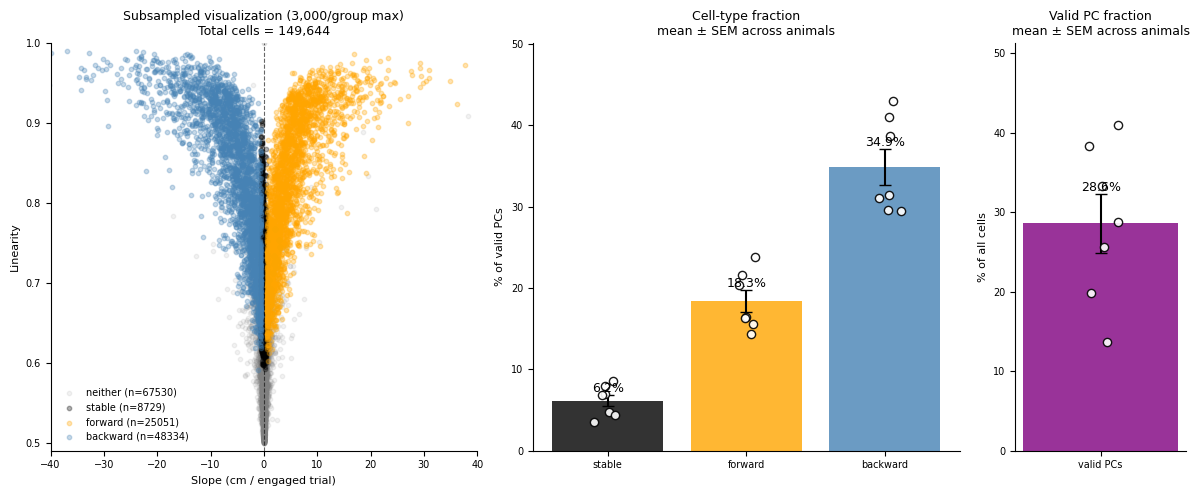

In [22]:
EPS = 1e-6

colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray",
    "valid_pc": "purple"}

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

plot_labels = ["neither", "stable", "forward", "backward"]
summary_labels = ["stable", "forward", "backward"]

# -------------------------
# Clean data
# -------------------------
df = df_pf_dynamics.copy()

d = df[df["is_valid_pc"]].copy()
d = d[np.isfinite(d["slope"]) & np.isfinite(d["linearity"])]
d["yplot"] = d["linearity"] + EPS

animals_use = sorted(df["animal"].dropna().unique())

# Animal-level summary:
# % of valid PCs that are stable/fw/bw
animal_summary = []

for animal in animals_use:
    da = d[d["animal"] == animal]
    n_valid = len(da)

    row = {"animal": animal, "n_valid": n_valid}

    for lab in summary_labels:
        row[lab] = 100 * np.mean(da["label"] == lab) if n_valid > 0 else np.nan

    animal_summary.append(row)

animal_summary = pd.DataFrame(animal_summary)

# Animal-level % valid PCs
# denominator = all cells/rows in df_pf_dynamics per animal
valid_summary = []

for animal in animals_use:
    da_all = df[df["animal"] == animal]
    n_all = len(da_all)
    n_valid = np.sum(da_all["is_valid_pc"])

    valid_summary.append({
        "animal": animal,
        "n_all": n_all,
        "n_valid": n_valid,
        "valid_pc_percent": 100 * n_valid / n_all if n_all > 0 else np.nan})

valid_summary = pd.DataFrame(valid_summary)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1, .4]})

# -------------------------
# Scatter — rasterized for lightweight PDF
# -------------------------
# -------------------------
# Scatter — subsampled
# -------------------------
ax = axes[0]

N_PER_GROUP = 3000  # adjust as desired

rng = np.random.default_rng(0)

for lab in plot_labels:

    dd = d[d["label"] == lab]

    if len(dd) > N_PER_GROUP:
        idx = rng.choice(len(dd), N_PER_GROUP, replace=False)
        dd_plot = dd.iloc[idx]
    else:
        dd_plot = dd

    ax.scatter(
        dd_plot["slope"],
        dd_plot["yplot"],
        s=10,
        color=colors[lab],
        alpha=0.3 if lab != "neither" else 0.1,
        label=f"{lab} (n={len(dd)})"
    )

ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.6)
ax.set_xlim([-40, 40])
ax.set_ylim([0.49, 1])
ax.set_xlabel("Slope (cm / engaged trial)")
ax.set_ylabel("Linearity")
ax.set_title(
    f"Subsampled visualization ({N_PER_GROUP:,}/group max)\n"
    f"Total cells = {len(d):,}"
)
ax.legend(frameon=False, fontsize=7)

# Bar plot: stable/fw/bw across animals
ax = axes[1]
x = np.arange(len(summary_labels))
means = animal_summary[summary_labels].mean(axis=0).values
sems = animal_summary[summary_labels].sem(axis=0).values
ax.bar(x, means, yerr=sems, color=[colors[g] for g in summary_labels], alpha=0.8, capsize=4)

# individual animals
for i, lab in enumerate(summary_labels):
    y = animal_summary[lab].values
    jitter = np.random.normal(0, 0.05, size=len(y))
    ax.scatter(np.full(len(y), i) + jitter, y, color="white", edgecolor="k", s=35, zorder=3, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(summary_labels)
ax.set_ylabel("% of valid PCs")
ax.set_title("Cell-type fraction\nmean ± SEM across animals")

ymax = np.nanmax(means + sems) * 1.35
ax.set_ylim([0, ymax])

for i, v in enumerate(means):
    ax.text(i, v + sems[i], f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

# Bar plot: % valid PCs across animals
ax = axes[2]
valid_vals = valid_summary["valid_pc_percent"].values
valid_mean = np.nanmean(valid_vals)
valid_sem = pd.Series(valid_vals).sem()
ax.bar([0], [valid_mean], yerr=[valid_sem], color=colors["valid_pc"], alpha=0.8, capsize=4)
jitter = np.random.normal(0, 0.05, size=len(valid_vals))
ax.scatter(np.zeros(len(valid_vals)) + jitter, valid_vals, color="white", edgecolor="k", s=35, zorder=3, alpha=0.9)
ax.set_xticks([0])
ax.set_xticklabels(["valid PCs"])
ax.set_ylabel("% of all cells")
ax.set_title("Valid PC fraction\nmean ± SEM across animals")

ax.set_ylim([0, np.nanmax(valid_vals) * 1.25])
ax.text(0, valid_mean + valid_sem, f"{valid_mean:.1f}%", ha="center", va="bottom", fontsize=9)

# Style
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

save_path = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/single_cell_dynamics_summary.pdf"

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/single_cell_dynamics_summary_mono.pdf


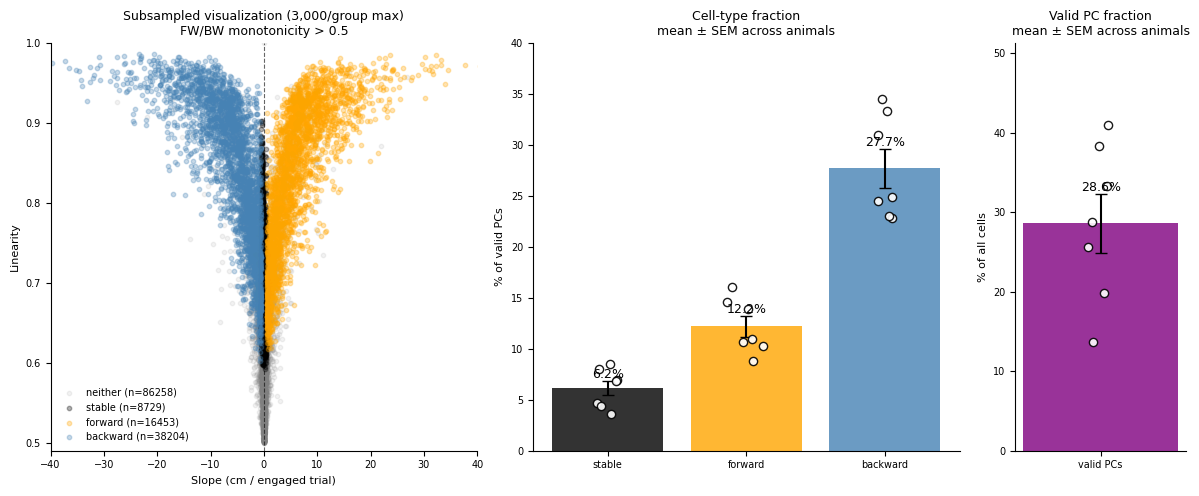

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EPS = 1e-6
MONO_PLOT_THRESH = 0.5
N_PER_GROUP = 3000

save_dir = Path("/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "single_cell_dynamics_summary_mono.pdf"

colors = {
    "backward": "steelblue",
    "stable": "black",
    "forward": "orange",
    "neither": "gray",
    "valid_pc": "purple"
}

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

plot_labels = ["neither", "stable", "forward", "backward"]
summary_labels = ["stable", "forward", "backward"]

# -------------------------
# Clean data
# -------------------------
df = df_pf_dynamics.copy()

d = df[df["is_valid_pc"]].copy()
d = d[np.isfinite(d["slope"]) & np.isfinite(d["linearity"])]
d["yplot"] = d["linearity"] + EPS

# -------------------------
# Monotonicity-refined labels
# -------------------------
d["label_mono"] = d["label"].copy()

bad_fw = (d["label"] == "forward") & (d["mono_fw"] <= MONO_PLOT_THRESH)
bad_bw = (d["label"] == "backward") & (d["mono_bw"] <= MONO_PLOT_THRESH)

d.loc[bad_fw | bad_bw, "label_mono"] = "neither"

animals_use = sorted(df["animal"].dropna().unique())

# -------------------------
# Animal-level summary:
# % of valid PCs that are stable/fw/bw
# -------------------------
animal_summary = []

for animal in animals_use:
    da = d[d["animal"] == animal]
    n_valid = len(da)

    row = {"animal": animal, "n_valid": n_valid}

    for lab in summary_labels:
        row[lab] = 100 * np.mean(da["label_mono"] == lab) if n_valid > 0 else np.nan

    animal_summary.append(row)

animal_summary = pd.DataFrame(animal_summary)

# -------------------------
# Animal-level % valid PCs
# denominator = all cells/rows in df_pf_dynamics per animal
# -------------------------
valid_summary = []

for animal in animals_use:
    da_all = df[df["animal"] == animal]
    n_all = len(da_all)
    n_valid = np.sum(da_all["is_valid_pc"])

    valid_summary.append({
        "animal": animal,
        "n_all": n_all,
        "n_valid": n_valid,
        "valid_pc_percent": 100 * n_valid / n_all if n_all > 0 else np.nan
    })

valid_summary = pd.DataFrame(valid_summary)

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1, 1, 0.4]}
)

# -------------------------
# Scatter — subsampled
# -------------------------
ax = axes[0]
rng = np.random.default_rng(0)

for lab in plot_labels:
    dd = d[d["label_mono"] == lab]

    if len(dd) > N_PER_GROUP:
        idx = rng.choice(len(dd), N_PER_GROUP, replace=False)
        dd_plot = dd.iloc[idx]
    else:
        dd_plot = dd

    ax.scatter(
        dd_plot["slope"],
        dd_plot["yplot"],
        s=10,
        color=colors[lab],
        alpha=0.3 if lab != "neither" else 0.1,
        label=f"{lab} (n={len(dd)})"
    )

ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.6)
ax.set_xlim([-40, 40])
ax.set_ylim([0.49, 1])
ax.set_xlabel("Slope (cm / engaged trial)")
ax.set_ylabel("Linearity")
ax.set_title(
    f"Subsampled visualization ({N_PER_GROUP:,}/group max)\n"
    f"FW/BW monotonicity > {MONO_PLOT_THRESH}"
)
ax.legend(frameon=False, fontsize=7)

# -------------------------
# Bar plot: stable/fw/bw across animals
# -------------------------
ax = axes[1]

x = np.arange(len(summary_labels))
means = animal_summary[summary_labels].mean(axis=0).values
sems = animal_summary[summary_labels].sem(axis=0).values

ax.bar(
    x,
    means,
    yerr=sems,
    color=[colors[g] for g in summary_labels],
    alpha=0.8,
    capsize=4
)

for i, lab in enumerate(summary_labels):
    y = animal_summary[lab].values
    jitter = rng.normal(0, 0.05, size=len(y))

    ax.scatter(
        np.full(len(y), i) + jitter,
        y,
        color="white",
        edgecolor="k",
        s=35,
        zorder=3,
        alpha=0.9
    )

ax.set_xticks(x)
ax.set_xticklabels(summary_labels)
ax.set_ylabel("% of valid PCs")
ax.set_title("Cell-type fraction\nmean ± SEM across animals")

ymax = np.nanmax(means + sems) * 1.35
ax.set_ylim([0, ymax])

for i, v in enumerate(means):
    ax.text(
        i,
        v + sems[i],
        f"{v:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -------------------------
# Bar plot: % valid PCs across animals
# -------------------------
ax = axes[2]

valid_vals = valid_summary["valid_pc_percent"].values
valid_mean = np.nanmean(valid_vals)
valid_sem = pd.Series(valid_vals).sem()

ax.bar(
    [0],
    [valid_mean],
    yerr=[valid_sem],
    color=colors["valid_pc"],
    alpha=0.8,
    capsize=4
)

jitter = rng.normal(0, 0.05, size=len(valid_vals))

ax.scatter(
    np.zeros(len(valid_vals)) + jitter,
    valid_vals,
    color="white",
    edgecolor="k",
    s=35,
    zorder=3,
    alpha=0.9
)

ax.set_xticks([0])
ax.set_xticklabels(["valid PCs"])
ax.set_ylabel("% of all cells")
ax.set_title("Valid PC fraction\nmean ± SEM across animals")

ax.set_ylim([0, np.nanmax(valid_vals) * 1.25])

ax.text(
    0,
    valid_mean + valid_sem,
    f"{valid_mean:.1f}%",
    ha="center",
    va="bottom",
    fontsize=9
)

# -------------------------
# Style and save
# -------------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved: {save_path}")

plt.show()

In [24]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

save_dir = Path("/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "single_cell_examples_1000_each_group.pdf"

rng = np.random.default_rng(0)

groups = ["stable", "backward", "forward"]
n_cells_plot = 1000
n_rows, n_cols = 50, 20

# cache PF_norm so we do not recompute same animal/session/trial_type repeatedly
pf_cache = {}

with PdfPages(save_path) as pdf:

    for group in groups:

        dg = df_pf_dynamics[
            (df_pf_dynamics["is_valid_pc"]) &
            (df_pf_dynamics["label"] == group)
        ].copy()

        if len(dg) > n_cells_plot:
            dg = dg.sample(n=n_cells_plot, random_state=0)
        else:
            print(f"Warning: only {len(dg)} cells found for {group}")

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(10, 20),
            constrained_layout=False
        )

        axes = axes.ravel()

        for ax in axes:
            ax.axis("off")

        for ax, (_, row) in zip(axes, dg.iterrows()):

            animal = row["animal"]
            sess = int(row["session"])
            trial_type = int(row["trial_type"])
            cell = int(row["cell"])

            key = (animal, sess, trial_type)

            if key not in pf_cache:

                data = Data_trial[animal]

                PF_all = np.asarray(data["fields"][sess], float)
                tt = np.asarray(data["trial_types"][sess])

                trial_idx = np.where(tt == trial_type)[0]
                PF = PF_all[trial_idx]

                engaged = get_engaged_trials(PF, z_threshold=z_threshold)
                PF_engaged = PF[engaged]

                _, _, _, _, _, PF_norm = detect_pf_emergence_norm01_v2(
                    PF_engaged,
                    bin_size=bin_size,
                    active_thresh=0.1,
                    min_consecutive_on=5,
                    min_consecutive_off=4,
                    in_out_ratio_thresh=2.0,
                    field_radius_bins=4,
                    field_activity_radius_bins=6
                )

                pf_cache[key] = PF_norm

            PF_norm = pf_cache[key]

            mat = PF_norm[:, cell, :]
            mat = fill_nan_local_mean(mat, size=3)
            ax.imshow(
                mat,
                aspect="auto",
                interpolation="nearest",
                cmap="viridis",
                vmin=0,
                vmax=1
            )

        plt.subplots_adjust(
            left=0,
            right=1,
            bottom=0,
            top=1,
            wspace=0.02,
            hspace=0.02
        )

        pdf.savefig(fig, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

print(f"Saved: {save_path}")

/tmp/ipykernel_5637/1899005892.py:640: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(mat_norm, axis=0)


Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/single_cell_examples_1000_each_group.pdf



Animal: Tyche-A4
  S00 TT1 | stable: n_cells=12
  S00 TT1 | backward: n_cells=570
  S00 TT1 | forward: n_cells=275
  S00 TT2 | backward: n_cells=447
  S00 TT2 | forward: n_cells=260
  S01 TT1 | stable: n_cells=39
  S01 TT1 | backward: n_cells=578
  S01 TT1 | forward: n_cells=240
  S01 TT2 | stable: n_cells=39
  S01 TT2 | backward: n_cells=579
  S01 TT2 | forward: n_cells=252
  S02 TT1 | stable: n_cells=13
  S02 TT1 | backward: n_cells=427
  S02 TT1 | forward: n_cells=193
  S02 TT2 | stable: n_cells=21
  S02 TT2 | backward: n_cells=477
  S02 TT2 | forward: n_cells=310
  S03 TT1 | stable: n_cells=55
  S03 TT1 | backward: n_cells=458
  S03 TT1 | forward: n_cells=256
  S03 TT2 | stable: n_cells=78
  S03 TT2 | backward: n_cells=405
  S03 TT2 | forward: n_cells=237
  S04 TT1 | stable: n_cells=171
  S04 TT1 | backward: n_cells=430
  S04 TT1 | forward: n_cells=248
  S04 TT2 | stable: n_cells=152
  S04 TT2 | backward: n_cells=525
  S04 TT2 | forward: n_cells=217
  S05 TT1 | stable: n_cells=133

/tmp/ipykernel_5637/1102755862.py:241: RuntimeWarning: Mean of empty slice
  shift_mat[i, j] = np.nanmean(shifts_cm)


  S07 TT1 | backward: n_cells=647
  S07 TT1 | forward: n_cells=399


/tmp/ipykernel_5637/1102755862.py:241: RuntimeWarning: Mean of empty slice
  shift_mat[i, j] = np.nanmean(shifts_cm)


  S07 TT2 | stable: n_cells=17
  S07 TT2 | backward: n_cells=711
  S07 TT2 | forward: n_cells=411


...

  S08 TT1 | backward: n_cells=556
  S08 TT1 | forward: n_cells=298
  S08 TT2 | stable: n_cells=44
  S08 TT2 | backward: n_cells=419


/tmp/ipykernel_5637/1102755862.py:241: RuntimeWarning: Mean of empty slice
  shift_mat[i, j] = np.nanmean(shifts_cm)


  S08 TT2 | forward: n_cells=248
  S09 TT1 | stable: n_cells=91
  S09 TT1 | backward: n_cells=471
  S09 TT1 | forward: n_cells=264
  S09 TT2 | stable: n_cells=65
  S09 TT2 | backward: n_cells=455
  S09 TT2 | forward: n_cells=238

Animal: Tyche-A5
  S00 TT1 | backward: n_cells=295
  S00 TT1 | forward: n_cells=132
  S00 TT2 | backward: n_cells=292
  S00 TT2 | forward: n_cells=158
  S01 TT1 | stable: n_cells=61
  S01 TT1 | backward: n_cells=452
  S01 TT1 | forward: n_cells=235
  S01 TT2 | stable: n_cells=26
  S01 TT2 | backward: n_cells=449
  S01 TT2 | forward: n_cells=229
  S02 TT1 | stable: n_cells=113
  S02 TT1 | backward: n_cells=506
  S02 TT1 | forward: n_cells=221
  S02 TT2 | stable: n_cells=99
  S02 TT2 | backward: n_cells=497
  S02 TT2 | forward: n_cells=285
  S03 TT1 | stable: n_cells=136
  S03 TT1 | backward: n_cells=396
  S03 TT1 | forward: n_cells=205
  S03 TT2 | stable: n_cells=132
  S03 TT2 | backward: n_cells=418
  S03 TT2 | forward: n_cells=218
  S04 TT1 | stable: n_cells=

/tmp/ipykernel_5637/1102755862.py:241: RuntimeWarning: Mean of empty slice
  shift_mat[i, j] = np.nanmean(shifts_cm)


  S01 TT2 | backward: n_cells=133
  S01 TT2 | forward: n_cells=74
  S02 TT1 | stable: n_cells=36
  S02 TT1 | backward: n_cells=232
  S02 TT1 | forward: n_cells=142
  S02 TT2 | stable: n_cells=54
  S02 TT2 | backward: n_cells=278
  S02 TT2 | forward: n_cells=139
  S03 TT1 | stable: n_cells=19
  S03 TT1 | backward: n_cells=256
  S03 TT1 | forward: n_cells=124
  S03 TT2 | stable: n_cells=16
  S03 TT2 | backward: n_cells=289
  S03 TT2 | forward: n_cells=132
  S04 TT1 | stable: n_cells=24
  S04 TT1 | backward: n_cells=190
  S04 TT1 | forward: n_cells=126
  S04 TT2 | stable: n_cells=33
  S04 TT2 | backward: n_cells=246
  S04 TT2 | forward: n_cells=136
  S05 TT1 | stable: n_cells=11
  S05 TT1 | backward: n_cells=173
  S05 TT1 | forward: n_cells=97
  S05 TT2 | backward: n_cells=182
  S05 TT2 | forward: n_cells=124
  S06 TT1 | stable: n_cells=51
  S06 TT1 | backward: n_cells=185
  S06 TT1 | forward: n_cells=109
  S06 TT2 | stable: n_cells=37
  S06 TT2 | backward: n_cells=205
  S06 TT2 | forward

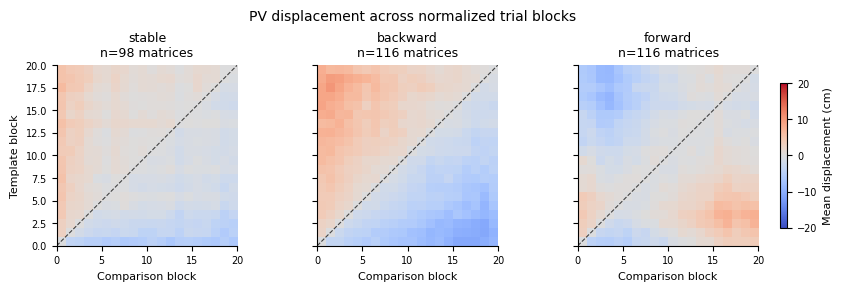


Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/PV_block20_displacement_subpopulations_original_logic.pdf


In [34]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

# ============================================================
# Parameters
# ============================================================

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "PV_block20_displacement_subpopulations_original_logic.pdf"
)

bin_size = 5
track_len = 230
alpha = 0.05
min_cells = 5
n_norm_blocks = 20

trial_types = [1, 2]
cell_groups = ["stable", "backward", "forward"]

vmin, vmax = -20, 20

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ============================================================
# Original PV correlation function
# ============================================================

def pv_corr_matrix_nan_safe_fast(PV1, PV2, min_cells=5):
    """
    PV1, PV2: cells x spatial_bins

    Returns:
        M: bin x bin population-vector correlation matrix
        P: bin x bin p-value matrix

    M[i, j] = correlation across cells between bin i in PV1
              and bin j in PV2.
    """

    X = np.asarray(PV1, float)
    Y = np.asarray(PV2, float)

    VX = np.isfinite(X).astype(float)
    VY = np.isfinite(Y).astype(float)

    X0 = np.nan_to_num(X, nan=0.0)
    Y0 = np.nan_to_num(Y, nan=0.0)

    N  = VX.T @ VY
    SX = X0.T @ VY
    SY = VX.T @ Y0

    with np.errstate(invalid="ignore", divide="ignore"):
        MX = SX / N
        MY = SY / N

        X2 = (X0 ** 2).T @ VY
        Y2 = VX.T @ (Y0 ** 2)
        XY = X0.T @ Y0

        cov = XY - N * MX * MY
        varX = X2 - N * MX ** 2
        varY = Y2 - N * MY ** 2

        denom = np.sqrt(varX * varY)

        M = cov / denom

        # p-value matrix
        df = N - 2
        t_stat = M * np.sqrt(df / (1 - M ** 2))
        P = 2 * t_dist.sf(np.abs(t_stat), df)

    bad = (N <= min_cells) | (denom <= 0) | (df <= 0)

    M[bad] = np.nan
    P[bad] = np.nan

    return M, P


# ============================================================
# Original displacement logic
# ============================================================

def displacement_from_M_centered_sig(
    M,
    P,
    bin_size=5,
    track_len=230,
    alpha=0.05
):
    """
    Converts a bin x bin PV correlation matrix into displacement.

    For each template bin i:
        1. keep only significant correlations
        2. center row i so diagonal = 0 cm displacement
        3. set negative correlations to 0
        4. compute weighted displacement

    Returns:
        shifts: length n_bins
    """

    n_bins = M.shape[1]
    disp = (np.arange(n_bins) - n_bins // 2) * bin_size

    shifts = np.full(M.shape[0], np.nan)

    for i in range(M.shape[0]):

        row = M[i].copy()

        # keep only significant correlations
        row[P[i] >= alpha] = np.nan

        # center template bin at zero displacement
        w = np.roll(row, n_bins // 2 - i)

        # negative correlations do not contribute
        w = np.clip(w, 0, None)

        if np.isfinite(w).sum() < 3 or np.nansum(w) == 0:
            continue

        shifts[i] = np.nansum(w * disp) / np.nansum(w)

    return shifts


# ============================================================
# Build exactly 20 blocks per session / trial type
# ============================================================

def build_20_normalized_blocks(PF, TT, trial_type=1, n_blocks=20):
    """
    PF: trials x cells x bins
    TT: trial type per trial

    Splits trials of a given trial type into exactly 20 normalized blocks.

    Returns:
        blocks: list of length 20
                each block is cells x bins
    """

    PF_tt = PF[np.asarray(TT) == trial_type]

    if PF_tt.shape[0] < n_blocks:
        return None

    edges = np.linspace(0, PF_tt.shape[0], n_blocks + 1).astype(int)

    blocks = []

    for b in range(n_blocks):

        start = edges[b]
        end = edges[b + 1]

        if end <= start:
            return None

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            block = np.nanmean(PF_tt[start:end], axis=0)  # cells x bins

        blocks.append(block)

    return blocks


# ============================================================
# Compute block x block displacement matrix for one subpopulation
# ============================================================

def block_pair_displacement_matrix_original_logic(
    blocks,
    cell_idx,
    alpha=0.05,
    min_cells=5,
    bin_size=5,
    track_len=230
):
    """
    blocks: list of 20 matrices, each cells x bins
    cell_idx: selected cells for one subpopulation

    Returns:
        shift_mat: 20 x 20 displacement matrix
    """

    n_blocks = len(blocks)
    shift_mat = np.full((n_blocks, n_blocks), np.nan)

    if len(cell_idx) < min_cells:
        return shift_mat

    # subset once for speed
    block_sub = [b[cell_idx, :] for b in blocks]

    for i in range(n_blocks):
        for j in range(n_blocks):

            M, P = pv_corr_matrix_nan_safe_fast(
                block_sub[i],
                block_sub[j],
                min_cells=min_cells
            )

            shifts_cm = displacement_from_M_centered_sig(
                M,
                P,
                bin_size=bin_size,
                track_len=track_len,
                alpha=alpha
            )

            shift_mat[i, j] = np.nanmean(shifts_cm)

    return shift_mat


# ============================================================
# Main analysis
# ============================================================

all_mats = {g: [] for g in cell_groups}
all_counts = {g: [] for g in cell_groups}
all_meta = {g: [] for g in cell_groups}

for animal in animals:

    print(f"\nAnimal: {animal}")

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    for sess in range(n_sessions):

        PF_all = np.asarray(data["fields"][sess], float)
        TT = np.asarray(data["trial_types"][sess])

        for trial_type in trial_types:

            blocks = build_20_normalized_blocks(
                PF_all,
                TT,
                trial_type=trial_type,
                n_blocks=n_norm_blocks
            )

            if blocks is None:
                continue

            df_sess = df_pf_dynamics[
                (df_pf_dynamics["animal"] == animal) &
                (df_pf_dynamics["session"] == sess) &
                (df_pf_dynamics["trial_type"] == trial_type) &
                (df_pf_dynamics["is_valid_pc"])
            ].copy()

            if len(df_sess) == 0:
                continue

            for group in cell_groups:

                cell_idx = (
                    df_sess.loc[df_sess["label"] == group, "cell"]
                    .dropna()
                    .astype(int)
                    .unique()
                )

                if len(cell_idx) < min_cells:
                    continue

                shift_mat = block_pair_displacement_matrix_original_logic(
                    blocks,
                    cell_idx,
                    alpha=alpha,
                    min_cells=min_cells,
                    bin_size=bin_size,
                    track_len=track_len
                )

                if np.isfinite(shift_mat).sum() == 0:
                    continue

                all_mats[group].append(shift_mat)
                all_counts[group].append(len(cell_idx))
                all_meta[group].append({
                    "animal": animal,
                    "session": sess,
                    "trial_type": trial_type,
                    "n_cells": len(cell_idx)
                })

                print(
                    f"  S{sess:02d} TT{trial_type} | "
                    f"{group}: n_cells={len(cell_idx)}"
                )


# ============================================================
# Average across animals, sessions, and trial types
# ============================================================

mean_mats = {}

for group in cell_groups:

    if len(all_mats[group]) == 0:
        mean_mats[group] = np.full((n_norm_blocks, n_norm_blocks), np.nan)
        print(f"{group}: no valid matrices")
        continue

    mats = np.stack(all_mats[group], axis=0)

    mean_mats[group] = np.nanmean(mats, axis=0)

    print(
        f"\n{group}:"
        f"\n  n matrices = {len(all_mats[group])}"
        f"\n  mean n cells = {np.nanmean(all_counts[group]):.1f}"
        f"\n  min/max n cells = {np.nanmin(all_counts[group])} / {np.nanmax(all_counts[group])}"
    )


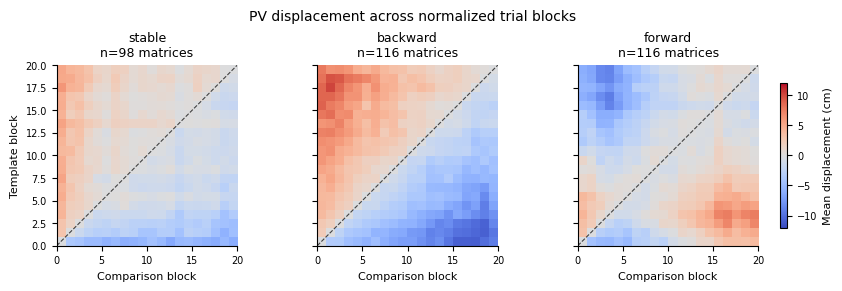


Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/PV_block20_displacement_subpopulations_original_logic.pdf


In [38]:

# ============================================================
# Plot 1 x 3 summary figure
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(8.5, 2.8),
    constrained_layout=True,
    sharex=True,
    sharey=True)

im = None

for ax, group in zip(axes, cell_groups):

    mat = mean_mats[group]

    im = ax.imshow(
        mat,
        cmap="coolwarm",
        vmin=-12,
        vmax=12,
        origin="lower",
        aspect="equal",
        interpolation="none",
        extent=[0, n_norm_blocks, 0, n_norm_blocks])

    ax.plot(
        [0, n_norm_blocks],
        [0, n_norm_blocks],
        "--k",
        lw=0.8,
        alpha=0.7)

    ax.set_title(f"{group}\n" f"n={len(all_mats[group])} matrices")

    ax.set_xlabel("Comparison block")

axes[0].set_ylabel("Template block")

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)

cbar.set_label("Mean displacement (cm)")

fig.suptitle("PV displacement across normalized trial blocks", fontsize=10)

fig.savefig(save_path,bbox_inches="tight", transparent=True)

plt.show()

print(f"\nSaved:\n{save_path}")

In [40]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from scipy.stats import t as t_dist

# ============================================================
# Parameters
# ============================================================

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

bin_size = 5
track_len = 230
alpha = 0.05
min_cells = 5
block_size = 3
trial_types = [1, 2]


# ============================================================
# Original PV correlation logic
# ============================================================

def pv_corr_matrix_nan_safe_fast(PV1, PV2, min_cells=5):
    X = np.asarray(PV1, float)
    Y = np.asarray(PV2, float)

    VX = np.isfinite(X).astype(float)
    VY = np.isfinite(Y).astype(float)

    X0 = np.nan_to_num(X, nan=0.0)
    Y0 = np.nan_to_num(Y, nan=0.0)

    N  = VX.T @ VY
    SX = X0.T @ VY
    SY = VX.T @ Y0

    with np.errstate(invalid="ignore", divide="ignore"):
        MX = SX / N
        MY = SY / N

        X2 = (X0 ** 2).T @ VY
        Y2 = VX.T @ (Y0 ** 2)
        XY = X0.T @ Y0

        cov = XY - N * MX * MY
        varX = X2 - N * MX ** 2
        varY = Y2 - N * MY ** 2

        denom = np.sqrt(varX * varY)
        M = cov / denom

        df = N - 2
        t_stat = M * np.sqrt(df / (1 - M ** 2))
        P = 2 * t_dist.sf(np.abs(t_stat), df)

    bad = (N <= min_cells) | (denom <= 0) | (df <= 0)

    M[bad] = np.nan
    P[bad] = np.nan

    return M, P


def displacement_from_M_centered_sig(
    M,
    P,
    bin_size=5,
    track_len=230,
    alpha=0.05
):
    n_bins = M.shape[1]
    disp = (np.arange(n_bins) - n_bins // 2) * bin_size

    shifts = np.full(M.shape[0], np.nan)

    for i in range(M.shape[0]):

        row = M[i].copy()
        row[P[i] >= alpha] = np.nan

        w = np.roll(row, n_bins // 2 - i)
        w = np.clip(w, 0, None)

        if np.isfinite(w).sum() < 3 or np.nansum(w) == 0:
            continue

        shifts[i] = np.nansum(w * disp) / np.nansum(w)

    return shifts


# ============================================================
# Block construction
# ============================================================

def build_trial_blocks(PF, block_size=3):
    """
    PF: trials x cells x bins

    Returns:
        blocks: list of cells x bins matrices
    """

    n_trials = PF.shape[0]
    n_blocks = n_trials // block_size

    if n_blocks < 2:
        return None

    blocks = []

    for b in range(n_blocks):

        start = b * block_size
        end = (b + 1) * block_size

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            block = np.nanmean(PF[start:end], axis=0)

        blocks.append(block)

    return blocks


def block_pair_displacement_matrix_original_logic(
    blocks,
    cell_idx,
    alpha=0.05,
    min_cells=5,
    bin_size=5,
    track_len=230
):
    n_blocks = len(blocks)
    shift_mat = np.full((n_blocks, n_blocks), np.nan)

    if len(cell_idx) < min_cells:
        return shift_mat

    block_sub = [b[cell_idx, :] for b in blocks]

    for i in range(n_blocks):
        for j in range(n_blocks):

            M, P = pv_corr_matrix_nan_safe_fast(
                block_sub[i],
                block_sub[j],
                min_cells=min_cells
            )

            shifts_cm = displacement_from_M_centered_sig(
                M,
                P,
                bin_size=bin_size,
                track_len=track_len,
                alpha=alpha
            )

            shift_mat[i, j] = np.nanmean(shifts_cm)

    return shift_mat


# ============================================================
# Peak-alignment control
# ============================================================

def circular_align_each_cell_to_reference_trial(PF):
    """
    PF: trials x cells x bins

    For each cell:
        1. find trial with largest response
        2. use that trial's peak as reference
        3. circularly shift every trial so its peak aligns to reference peak
    """

    PF = np.asarray(PF, float)
    PF_aligned = PF.copy()

    n_trials, n_cells, n_bins = PF.shape
    info = []

    for cell in range(n_cells):

        mat = PF[:, cell, :]  # trials x bins

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            trial_response = np.nanmax(mat, axis=1)

        if np.all(~np.isfinite(trial_response)):
            info.append({
                "cell": cell,
                "ref_trial": np.nan,
                "ref_peak_bin": np.nan
            })
            continue

        ref_trial = int(np.nanargmax(trial_response))
        ref_vec = mat[ref_trial]

        if np.all(~np.isfinite(ref_vec)):
            info.append({
                "cell": cell,
                "ref_trial": np.nan,
                "ref_peak_bin": np.nan
            })
            continue

        ref_peak = int(np.nanargmax(ref_vec))

        for tr in range(n_trials):

            vec = mat[tr]

            if np.all(~np.isfinite(vec)):
                continue

            peak = int(np.nanargmax(vec))
            shift = ref_peak - peak

            PF_aligned[tr, cell, :] = np.roll(vec, shift)

        info.append({
            "cell": cell,
            "ref_trial": ref_trial,
            "ref_peak_bin": ref_peak
        })

    return PF_aligned, pd.DataFrame(info)


# ============================================================
# Main function: all cells
# ============================================================

def run_block3_allcell_displacement(
    Data_trial,
    animals,
    do_peak_alignment=False,
    block_size=3,
    trial_types=[1, 2],
    alpha=0.05,
    min_cells=5,
    bin_size=5,
    track_len=230
):
    """
    results[animal][session][trial_type] = {
        "shift_mat": block x block displacement matrix,
        "n_blocks": number of blocks,
        "n_cells": number of cells,
        "cell_idx": all included cells,
        "align_info": only for peak-aligned run
    }
    """

    results = {}

    for animal in animals:

        print(f"\nAnimal: {animal}")
        results[animal] = {}

        data = Data_trial[animal]
        n_sessions = len(data["fields"])

        for sess in range(n_sessions):

            PF_all = np.asarray(data["fields"][sess], float)
            TT = np.asarray(data["trial_types"][sess])

            results[animal][sess] = {}

            for trial_type in trial_types:

                print(f"  Session {sess} | TT{trial_type}")

                trial_idx = np.where(TT == trial_type)[0]

                if len(trial_idx) < block_size * 2:
                    continue

                PF_tt = PF_all[trial_idx]

                align_info = None

                if do_peak_alignment:
                    PF_tt, align_info = circular_align_each_cell_to_reference_trial(PF_tt)

                blocks = build_trial_blocks(
                    PF_tt,
                    block_size=block_size
                )

                if blocks is None:
                    continue

                n_cells = PF_tt.shape[1]
                cell_idx = np.arange(n_cells)

                shift_mat = block_pair_displacement_matrix_original_logic(
                    blocks,
                    cell_idx,
                    alpha=alpha,
                    min_cells=min_cells,
                    bin_size=bin_size,
                    track_len=track_len
                )

                results[animal][sess][trial_type] = {
                    "shift_mat": shift_mat,
                    "n_blocks": len(blocks),
                    "n_cells": n_cells,
                    "cell_idx": cell_idx,
                    "block_size": block_size,
                    "trial_type": trial_type,
                    "animal": animal,
                    "session": sess,
                    "peak_aligned": do_peak_alignment,
                    "align_info": align_info
                }

                print(
                    f"    all cells: n_cells={n_cells}, "
                    f"n_blocks={len(blocks)}"
                )

    return results


# ============================================================
# Run 1: original data
# ============================================================

block3_allcell_disp_results = run_block3_allcell_displacement(
    Data_trial=Data_trial,
    animals=animals,
    do_peak_alignment=False,
    block_size=block_size,
    trial_types=trial_types,
    alpha=alpha,
    min_cells=min_cells,
    bin_size=bin_size,
    track_len=track_len
)


# ============================================================
# Run 2: peak-aligned data
# ============================================================

block3_allcell_disp_results_peak_aligned = run_block3_allcell_displacement(
    Data_trial=Data_trial,
    animals=animals,
    do_peak_alignment=True,
    block_size=block_size,
    trial_types=trial_types,
    alpha=alpha,
    min_cells=min_cells,
    bin_size=bin_size,
    track_len=track_len
)


# ============================================================
# Save both datasets
# ============================================================

save_path_normal = os.path.join(
    save_dir,
    "block3_allcell_displacement_original.pkl"
)

save_path_aligned = os.path.join(
    save_dir,
    "block3_allcell_displacement_peak_aligned.pkl"
)

with open(save_path_normal, "wb") as f:
    pickle.dump(block3_allcell_disp_results, f)

with open(save_path_aligned, "wb") as f:
    pickle.dump(block3_allcell_disp_results_peak_aligned, f)

print("\nSaved:")
print(save_path_normal)
print(save_path_aligned)


Animal: Tyche-A4
  Session 0 | TT1
    all cells: n_cells=3906, n_blocks=11
  Session 0 | TT2
    all cells: n_cells=3906, n_blocks=8
  Session 1 | TT1
    all cells: n_cells=3906, n_blocks=10
  Session 1 | TT2
    all cells: n_cells=3906, n_blocks=10
  Session 2 | TT1
    all cells: n_cells=3906, n_blocks=8
  Session 2 | TT2
    all cells: n_cells=3906, n_blocks=8
  Session 3 | TT1
    all cells: n_cells=3906, n_blocks=10
  Session 3 | TT2
    all cells: n_cells=3906, n_blocks=12
  Session 4 | TT1
    all cells: n_cells=3906, n_blocks=16
  Session 4 | TT2
    all cells: n_cells=3906, n_blocks=15
  Session 5 | TT1
    all cells: n_cells=3906, n_blocks=14
  Session 5 | TT2
    all cells: n_cells=3906, n_blocks=11
  Session 6 | TT1
    all cells: n_cells=3906, n_blocks=18
  Session 6 | TT2
    all cells: n_cells=3906, n_blocks=19
  Session 7 | TT1
    all cells: n_cells=3906, n_blocks=19
  Session 7 | TT2
    all cells: n_cells=3906, n_blocks=21
  Session 8 | TT1
    all cells: n_cells=

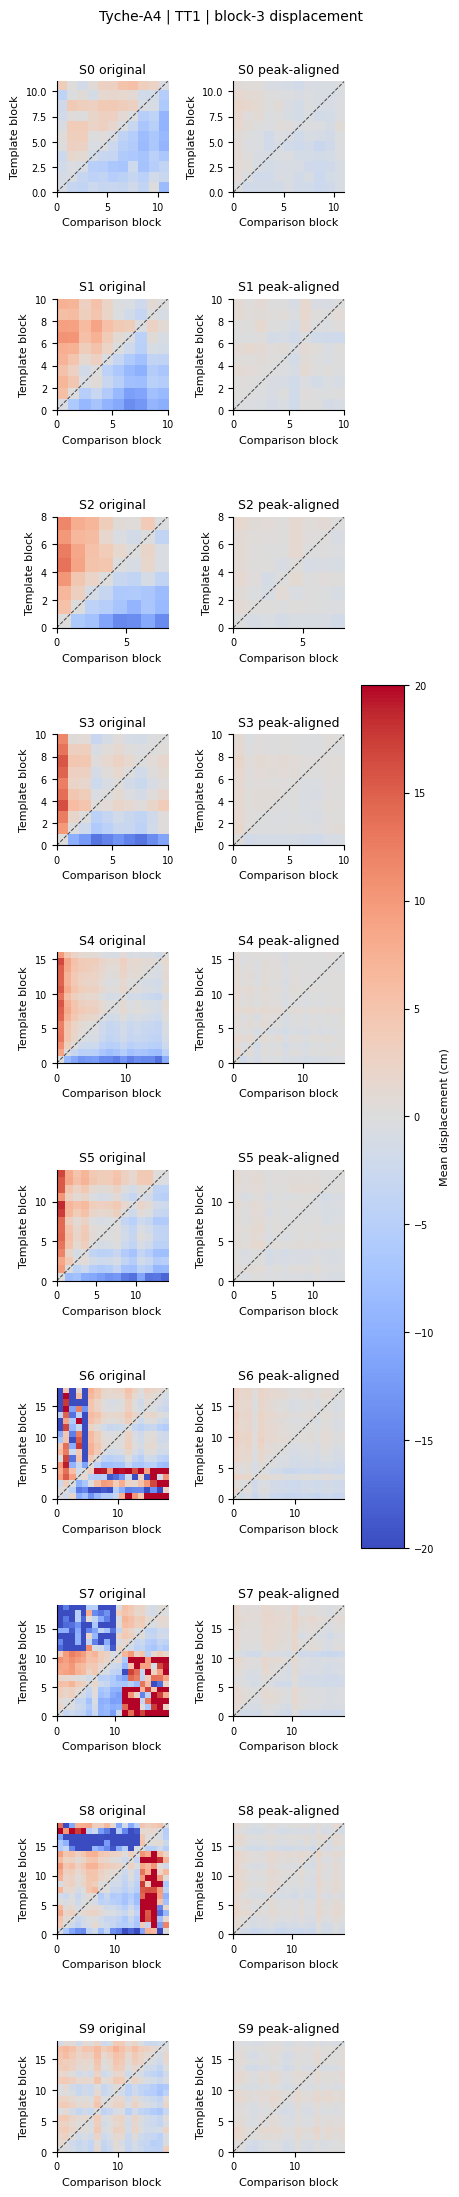

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-A4.pdf


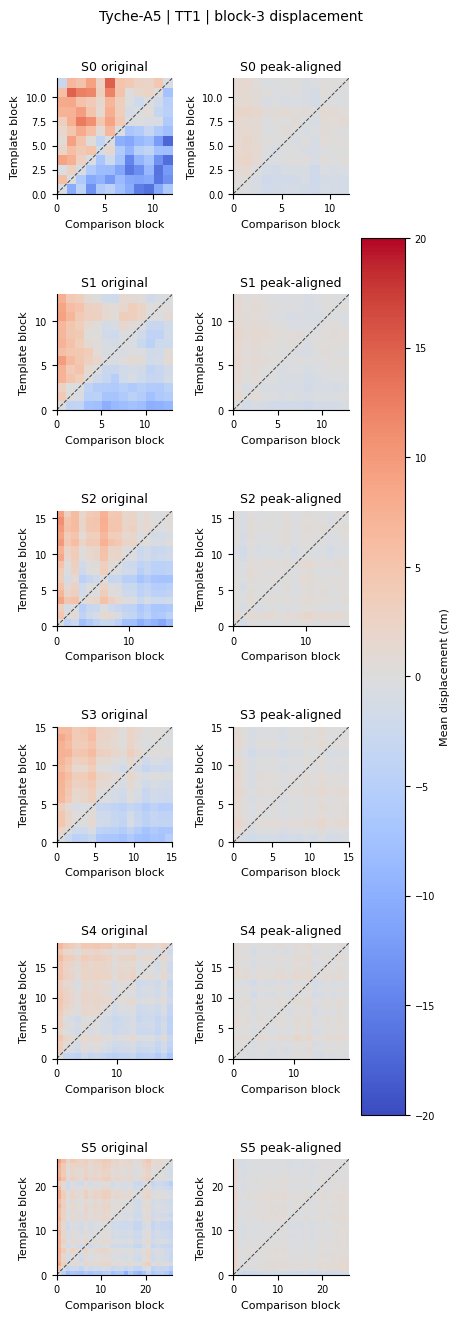

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-A5.pdf


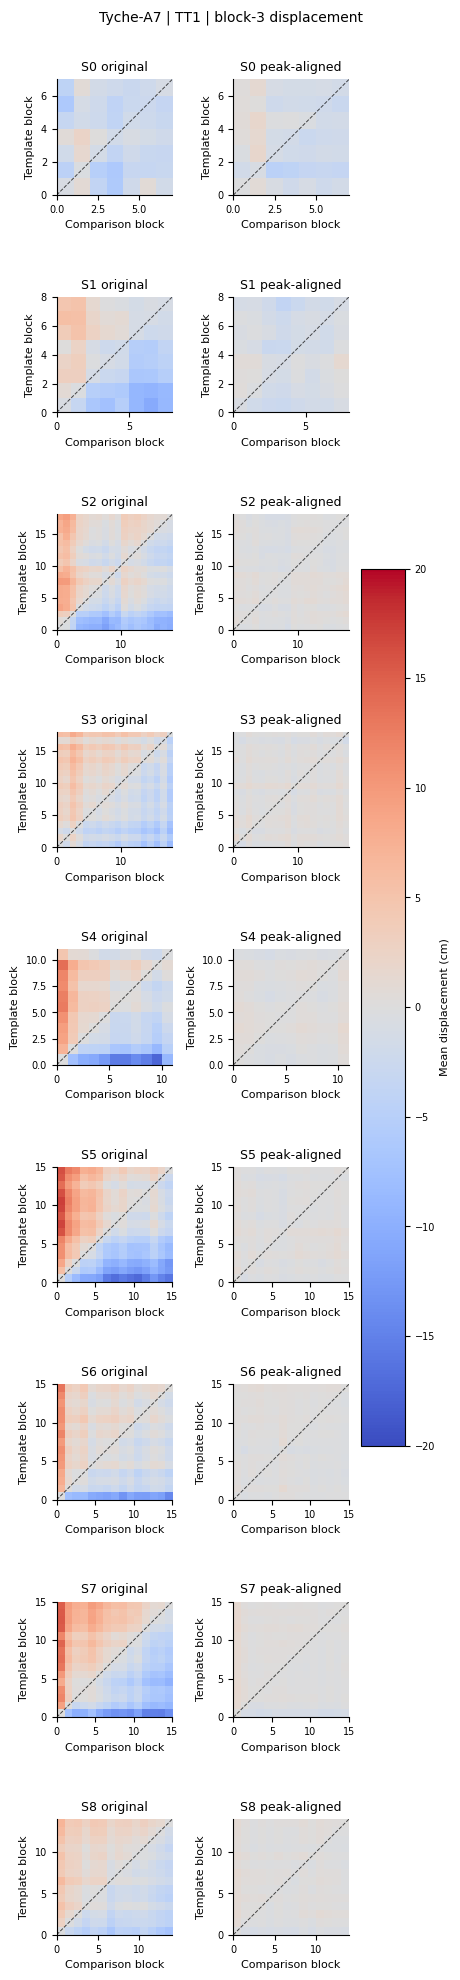

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-A7.pdf


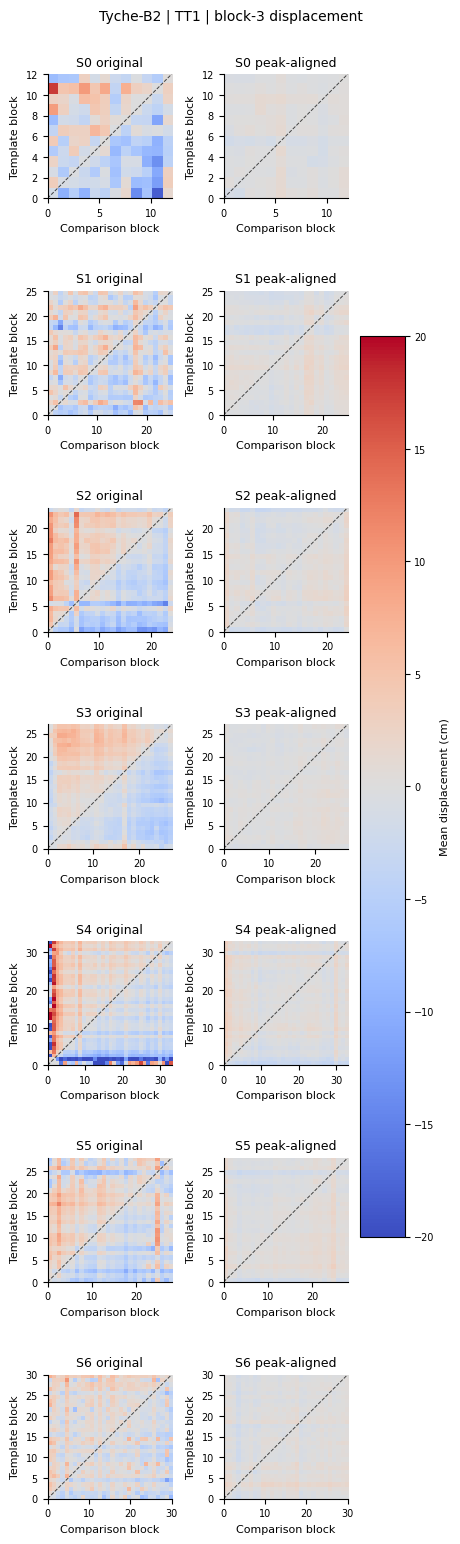

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-B2.pdf


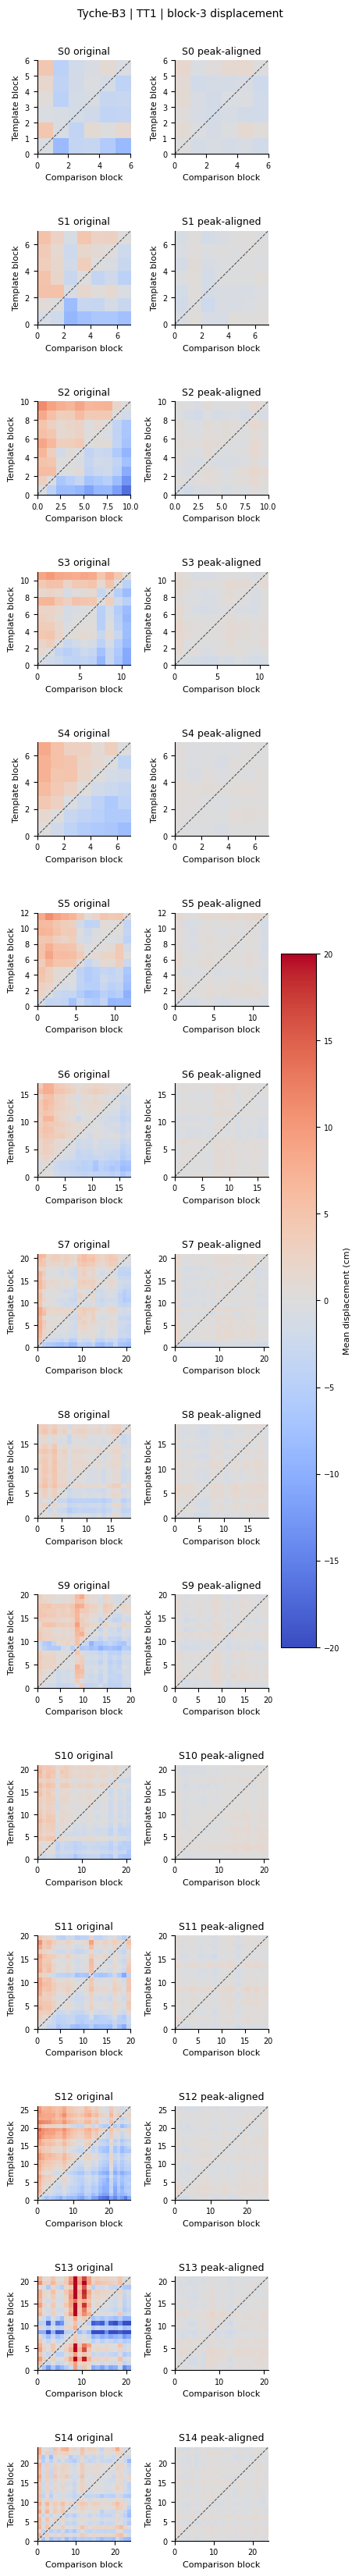

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-B3.pdf


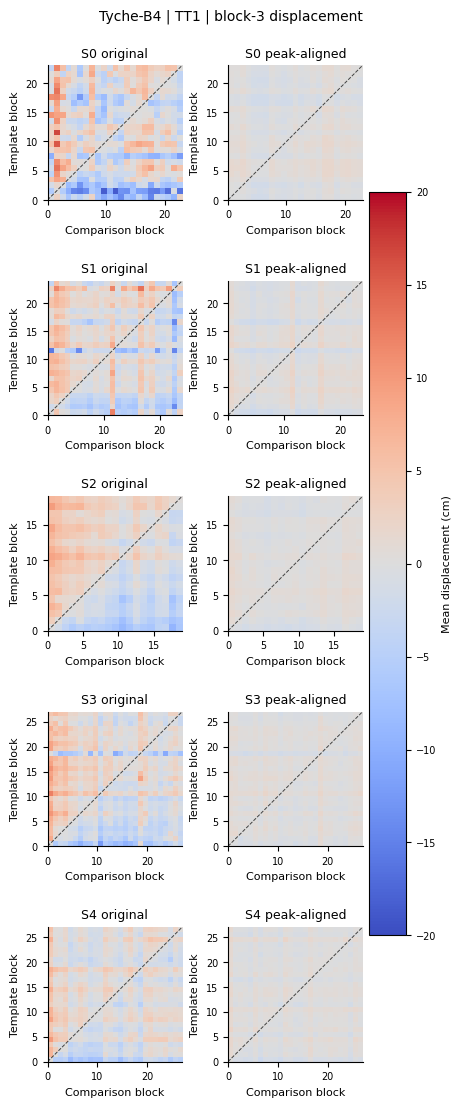

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-B4.pdf


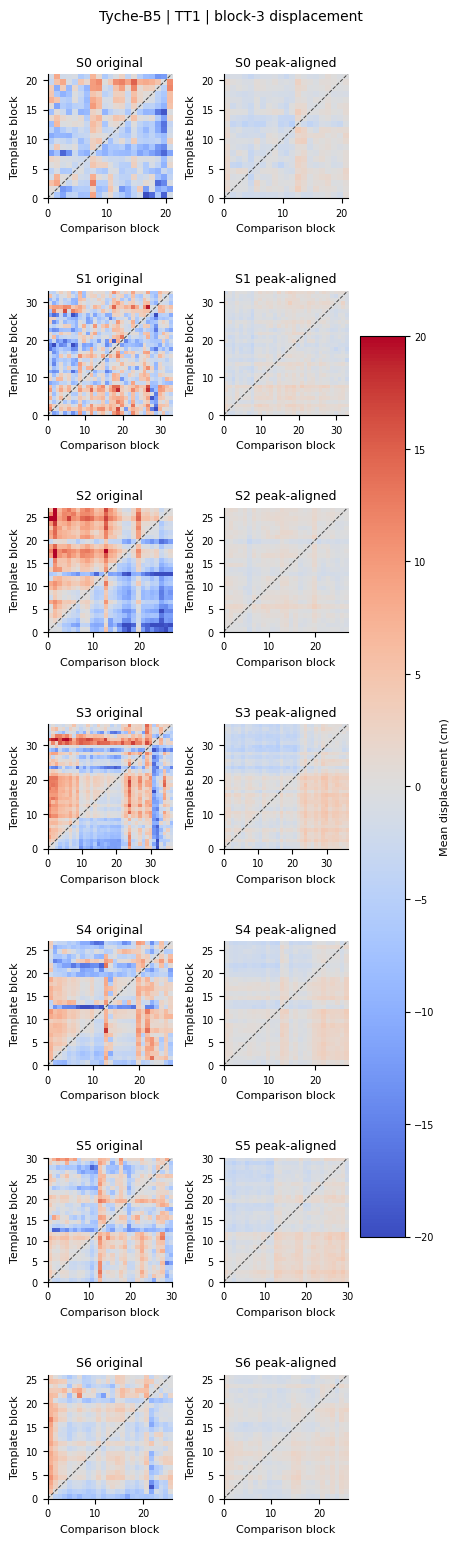

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_TT1_original_vs_peak_aligned_Tyche-B5.pdf


In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Parameters
# ============================================================

save_dir = Path("/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "block3_allcell_TT1_original_vs_peak_aligned_by_session.pdf"

trial_type = 1
vmin, vmax = -20, 20

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ============================================================
# Plot original and peak-aligned next to each other
# ============================================================

for animal in animals:

    sessions = sorted(block3_allcell_disp_results.get(animal, {}).keys())

    valid_sessions = []

    for sess in sessions:
        has_original = (
            sess in block3_allcell_disp_results[animal] and
            trial_type in block3_allcell_disp_results[animal][sess]
        )

        has_aligned = (
            sess in block3_allcell_disp_results_peak_aligned[animal] and
            trial_type in block3_allcell_disp_results_peak_aligned[animal][sess]
        )

        if has_original and has_aligned:
            valid_sessions.append(sess)

    if len(valid_sessions) == 0:
        continue

    nrows = len(valid_sessions)
    ncols = 2

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.5, 2.2 * nrows),
        squeeze=False,
        constrained_layout=True
    )

    im = None

    for r, sess in enumerate(valid_sessions):

        mat_original = block3_allcell_disp_results[animal][sess][trial_type]["shift_mat"]
        mat_aligned = block3_allcell_disp_results_peak_aligned[animal][sess][trial_type]["shift_mat"]

        n_blocks_original = mat_original.shape[0]
        n_blocks_aligned = mat_aligned.shape[0]

        # -------------------------
        # Original
        # -------------------------
        ax = axes[r, 0]

        im = ax.imshow(
            mat_original,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax,
            origin="lower",
            aspect="equal",
            interpolation="none",
            extent=[0, n_blocks_original, 0, n_blocks_original]
        )

        ax.plot(
            [0, n_blocks_original],
            [0, n_blocks_original],
            "--k",
            lw=0.7,
            alpha=0.7
        )

        ax.set_title(f"S{sess} original")
        ax.set_xlabel("Comparison block")
        ax.set_ylabel("Template block")

        # -------------------------
        # Peak-aligned
        # -------------------------
        ax = axes[r, 1]

        im = ax.imshow(
            mat_aligned,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax,
            origin="lower",
            aspect="equal",
            interpolation="none",
            extent=[0, n_blocks_aligned, 0, n_blocks_aligned]
        )

        ax.plot(
            [0, n_blocks_aligned],
            [0, n_blocks_aligned],
            "--k",
            lw=0.7,
            alpha=0.7
        )

        ax.set_title(f"S{sess} peak-aligned")
        ax.set_xlabel("Comparison block")
        ax.set_ylabel("Template block")

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        shrink=0.7,
        pad=0.02
    )

    cbar.set_label("Mean displacement (cm)")

    fig.suptitle(
        f"{animal} | TT{trial_type} | block-3 displacement",
        fontsize=10
    )

    animal_save_path = save_dir / f"block3_allcell_TT{trial_type}_original_vs_peak_aligned_{animal}.pdf"

    fig.savefig(
        animal_save_path,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()

    print(f"Saved: {animal_save_path}")

TT1: normal n=59, peak-aligned n=59
TT2: normal n=59, peak-aligned n=59


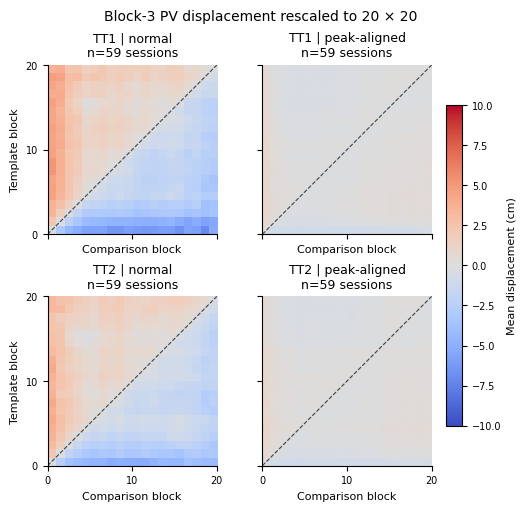

Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/block3_allcell_20x20_avg_normal_vs_peak_aligned_TT1_TT2.pdf


In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom

# ============================================================
# Parameters
# ============================================================

save_dir = Path("/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "block3_allcell_20x20_avg_normal_vs_peak_aligned_TT1_TT2.pdf"

target_size = 20
trial_types = [1, 2]
vmin, vmax = -10, 10

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ============================================================
# Resize matrix to 20 x 20
# ============================================================

def resize_matrix_to_20(mat, target_size=20):
    mat = np.asarray(mat, float)

    if mat.ndim != 2:
        return None

    if mat.shape[0] < 2 or mat.shape[1] < 2:
        return None

    zoom_factors = (
        target_size / mat.shape[0],
        target_size / mat.shape[1]
    )

    mat_resized = zoom(
        mat,
        zoom=zoom_factors,
        order=1,          # bilinear interpolation
        mode="nearest"
    )

    return mat_resized[:target_size, :target_size]


# ============================================================
# Collect and average matrices
# ============================================================

def collect_rescaled_mats(results, trial_type=1, target_size=20):
    mats = []

    for animal in results:

        for sess in results[animal]:

            if trial_type not in results[animal][sess]:
                continue

            mat = results[animal][sess][trial_type]["shift_mat"]

            mat20 = resize_matrix_to_20(
                mat,
                target_size=target_size
            )

            if mat20 is None:
                continue

            if np.isfinite(mat20).sum() == 0:
                continue

            mats.append(mat20)

    return mats


summary = {}

for trial_type in trial_types:

    normal_mats = collect_rescaled_mats(
        block3_allcell_disp_results,
        trial_type=trial_type,
        target_size=target_size
    )

    aligned_mats = collect_rescaled_mats(
        block3_allcell_disp_results_peak_aligned,
        trial_type=trial_type,
        target_size=target_size
    )

    summary[trial_type] = {
        "normal_mats": normal_mats,
        "aligned_mats": aligned_mats,
        "normal_mean": np.nanmean(np.stack(normal_mats), axis=0),
        "aligned_mean": np.nanmean(np.stack(aligned_mats), axis=0),
        "n_normal": len(normal_mats),
        "n_aligned": len(aligned_mats),
    }

    print(
        f"TT{trial_type}: "
        f"normal n={len(normal_mats)}, "
        f"peak-aligned n={len(aligned_mats)}"
    )


# ============================================================
# Plot 2 x 2 figure
# rows = trial type
# columns = normal vs peak-aligned
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(5.2, 5),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

im = None

for r, trial_type in enumerate(trial_types):

    plot_items = [
        ("normal", summary[trial_type]["normal_mean"], summary[trial_type]["n_normal"]),
        ("peak-aligned", summary[trial_type]["aligned_mean"], summary[trial_type]["n_aligned"]),
    ]

    for c, (name, mat, n_mats) in enumerate(plot_items):

        ax = axes[r, c]

        im = ax.imshow(
            mat,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax,
            origin="lower",
            aspect="equal",
            interpolation="none",
            extent=[0, target_size, 0, target_size]
        )

        ax.plot(
            [0, target_size],
            [0, target_size],
            "--k",
            lw=0.8,
            alpha=0.7
        )

        ax.set_title(f"TT{trial_type} | {name}\nn={n_mats} sessions")
        ax.set_xlabel("Comparison block")

        if c == 0:
            ax.set_ylabel("Template block")

        ax.set_xticks([0, 10, 20])
        ax.set_yticks([0, 10, 20])

cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.8,
    pad=0.02
)

cbar.set_label("Mean displacement (cm)")

fig.suptitle(
    "Block-3 PV displacement rescaled to 20 × 20",
    fontsize=10
)

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

plt.show()

print(f"Saved: {save_path}")

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

save_dir = Path("/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper")
save_dir.mkdir(parents=True, exist_ok=True)

save_path_original = save_dir / "example_1000_cells_original.pdf"
save_path_aligned  = save_dir / "example_1000_cells_peak_aligned.pdf"

N_CELLS = 1000
N_ROWS, N_COLS = 50, 20
trial_types = [1, 2]
rng = np.random.default_rng(0)


def norm01(mat):
    mat = np.asarray(mat, float)
    mn = np.nanmin(mat)
    mx = np.nanmax(mat)
    if not np.isfinite(mn) or not np.isfinite(mx) or mx <= mn:
        return mat * np.nan
    return (mat - mn) / (mx - mn)


def circular_align_single_cell(mat):
    """
    mat: trials x bins
    """

    mat = np.asarray(mat, float)
    aligned = mat.copy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        trial_response = np.nanmax(mat, axis=1)

    if np.all(~np.isfinite(trial_response)):
        return aligned

    ref_trial = int(np.nanargmax(trial_response))
    ref_peak = int(np.nanargmax(mat[ref_trial]))

    for tr in range(mat.shape[0]):
        vec = mat[tr]

        if np.all(~np.isfinite(vec)):
            continue

        peak = int(np.nanargmax(vec))
        shift = ref_peak - peak
        aligned[tr] = np.roll(vec, shift)

    return aligned


# -------------------------
# Collect candidate cells
# -------------------------
cell_records = []

for animal in animals:
    data = Data_trial[animal]

    for sess in range(len(data["fields"])):

        PF_all = np.asarray(data["fields"][sess], float)  # trials x cells x bins
        TT = np.asarray(data["trial_types"][sess])

        n_cells = PF_all.shape[1]

        for trial_type in trial_types:

            trial_idx = np.where(TT == trial_type)[0]

            if len(trial_idx) < 5:
                continue

            for cell in range(n_cells):
                cell_records.append({
                    "animal": animal,
                    "session": sess,
                    "trial_type": trial_type,
                    "cell": cell
                })

print(f"Total candidate cells: {len(cell_records)}")

# -------------------------
# Sample 1000 cells
# -------------------------
if len(cell_records) > N_CELLS:
    sampled_idx = rng.choice(len(cell_records), N_CELLS, replace=False)
    sampled_records = [cell_records[i] for i in sampled_idx]
else:
    sampled_records = cell_records
    print(f"Warning: only {len(sampled_records)} cells available")

# -------------------------
# Extract original and aligned matrices
# -------------------------
original_mats = []
aligned_mats = []

for rec in sampled_records:

    animal = rec["animal"]
    sess = rec["session"]
    trial_type = rec["trial_type"]
    cell = rec["cell"]

    data = Data_trial[animal]

    PF_all = np.asarray(data["fields"][sess], float)
    TT = np.asarray(data["trial_types"][sess])

    trial_idx = np.where(TT == trial_type)[0]

    mat = PF_all[trial_idx, cell, :]  # trials x bins
    mat = norm01(mat)

    mat_aligned = circular_align_single_cell(mat)

    original_mats.append(fill_nan_local_mean(mat))
    aligned_mats.append(fill_nan_local_mean(mat_aligned, size=3))


# -------------------------
# Plot function
# -------------------------
def plot_cell_grid(mats, save_path, title=None):

    fig, axes = plt.subplots(
        N_ROWS,
        N_COLS,
        figsize=(10, 20),
        constrained_layout=False
    )

    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, mat in zip(axes, mats):

        ax.imshow(
            mat,
            aspect="auto",
            interpolation="nearest",
            cmap="viridis",
            vmin=0,
            vmax=1
        )

    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
        wspace=0.02,
        hspace=0.02
    )

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0,
        dpi=300
    )

    plt.close(fig)

    print(f"Saved: {save_path}")


# -------------------------
# Save both figures
# -------------------------
plot_cell_grid(original_mats, save_path_original)
plot_cell_grid(aligned_mats, save_path_aligned)

Total candidate cells: 491846
Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/example_1000_cells_original.pdf
Saved: /home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/example_1000_cells_peak_aligned.pdf


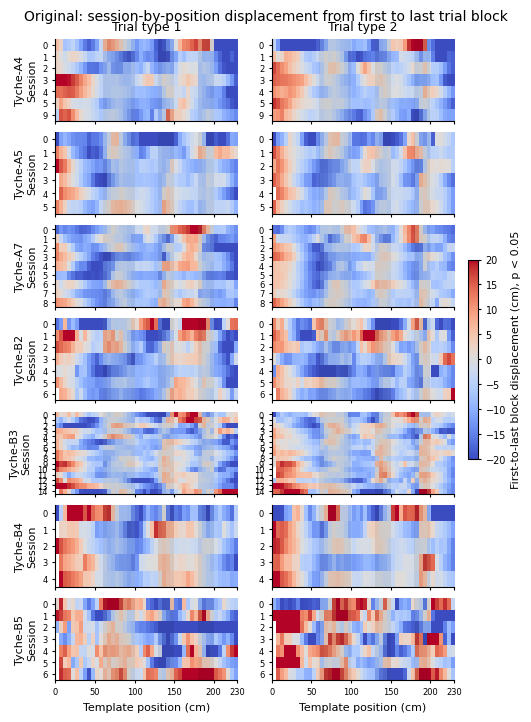

Saved PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/session_by_position_first_last_block_displacement_TT1_TT2_original.pdf


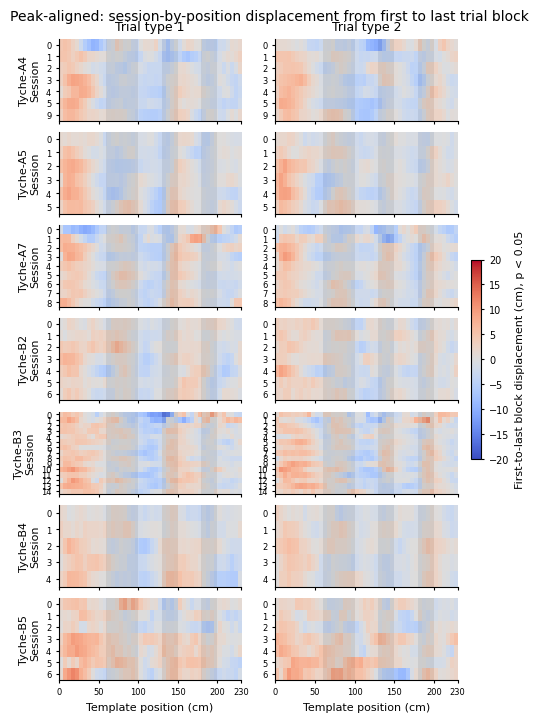

Saved PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/session_by_position_first_last_block_displacement_TT1_TT2_peak_aligned.pdf


In [48]:
# parameters
save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

first_trials = slice(5, 10)
last_n_trials = 5
alpha = 0.05
bin_size = 5
track_len = 230

vmin, vmax = -20, 20


# -------------------------------------------------------
# peak-align function
# -------------------------------------------------------

def circular_align_each_cell_to_reference_trial(PF):
    """
    PF: trials x cells x bins

    For each cell:
        1. find trial with largest response
        2. use that trial's peak as reference
        3. circularly shift every trial so its peak aligns to reference peak
    """

    PF = np.asarray(PF, float)
    PF_aligned = PF.copy()

    n_trials, n_cells, n_bins = PF.shape
    info = []

    for cell in range(n_cells):

        mat = PF[:, cell, :]  # trials x bins

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            trial_response = np.nanmax(mat, axis=1)

        if np.all(~np.isfinite(trial_response)):
            info.append({
                "cell": cell,
                "ref_trial": np.nan,
                "ref_peak_bin": np.nan
            })
            continue

        ref_trial = int(np.nanargmax(trial_response))
        ref_vec = mat[ref_trial]

        if np.all(~np.isfinite(ref_vec)):
            info.append({
                "cell": cell,
                "ref_trial": np.nan,
                "ref_peak_bin": np.nan
            })
            continue

        ref_peak = int(np.nanargmax(ref_vec))

        for tr in range(n_trials):

            vec = mat[tr]

            if np.all(~np.isfinite(vec)):
                continue

            peak = int(np.nanargmax(vec))
            shift = ref_peak - peak

            PF_aligned[tr, cell, :] = np.roll(vec, shift)

        info.append({
            "cell": cell,
            "ref_trial": ref_trial,
            "ref_peak_bin": ref_peak
        })

    return PF_aligned, pd.DataFrame(info)


# -------------------------------------------------------
# compute original and peak-aligned results
# -------------------------------------------------------

session_shift_matrix_by_group_animal_tt = {
    "original": {},
    "peak_aligned": {}
}

alignment_info_by_animal_tt_session = {}

for group in ["original", "peak_aligned"]:

    for animal in animals:

        session_shift_matrix_by_group_animal_tt[group][animal] = {}

        if group == "peak_aligned":
            alignment_info_by_animal_tt_session[animal] = {}

        for trial_type_to_use in [1, 2]:

            session_vectors = []
            session_ids = []

            if group == "peak_aligned":
                alignment_info_by_animal_tt_session[animal][trial_type_to_use] = {}

            for sess, (PF, TT) in enumerate(
                zip(Data_trial[animal]["fields"], Data_trial[animal]["trial_types"])
            ):

                if animal == animals[0] and sess in [6, 7, 8]:
                    continue

                TT = np.asarray(TT)
                PF_tt = PF[TT == trial_type_to_use]

                if len(PF_tt) < 10:
                    continue

                if group == "original":
                    PF_use = np.asarray(PF_tt, float)

                elif group == "peak_aligned":
                    PF_use, align_info = circular_align_each_cell_to_reference_trial(PF_tt)
                    alignment_info_by_animal_tt_session[animal][trial_type_to_use][sess] = align_info

                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=RuntimeWarning)

                    first_block = np.nanmean(PF_use[first_trials], axis=0)
                    last_block  = np.nanmean(PF_use[-last_n_trials:], axis=0)

                M, P = pv_corr_matrix_nan_safe_fast(
                    first_block,
                    last_block
                )

                shifts_cm = displacement_from_M_centered_sig(
                    M,
                    P,
                    bin_size=bin_size,
                    track_len=track_len,
                    alpha=alpha
                )

                session_vectors.append(shifts_cm)
                session_ids.append(sess)

            session_shift_matrix_by_group_animal_tt[group][animal][trial_type_to_use] = {
                "matrix": np.asarray(session_vectors),
                "sessions": np.asarray(session_ids)
            }


# convenient aliases
session_shift_matrix_by_animal_tt = session_shift_matrix_by_group_animal_tt["original"]
session_shift_matrix_peak_aligned_by_animal_tt = session_shift_matrix_by_group_animal_tt["peak_aligned"]


# -------------------------------------------------------
# plotting function
# -------------------------------------------------------

def plot_session_shift_matrix(
    session_shift_matrix_by_animal_tt,
    title,
    pdf_name,
    save_dir=save_dir,
    vmin=-20,
    vmax=20,
    alpha=0.05,
    track_len=230
):

    plt.rcParams.update({
        "font.size": 6,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })

    n_animals = len(animals)

    fig, axes = plt.subplots(
        n_animals,
        2,
        figsize=(5.2, 1.0 * n_animals),
        constrained_layout=True,
        sharex=True,
        sharey=False
    )

    if n_animals == 1:
        axes = axes[None, :]

    last_im = None

    for r, animal in enumerate(animals):

        for c, trial_type_to_use in enumerate([1, 2]):

            ax = axes[r, c]

            mat = session_shift_matrix_by_animal_tt[animal][trial_type_to_use]["matrix"]
            sessions = session_shift_matrix_by_animal_tt[animal][trial_type_to_use]["sessions"]

            if mat.size == 0:
                ax.text(
                    0.5,
                    0.5,
                    "No valid sessions",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=7
                )
                ax.set_title(f"TT{trial_type_to_use}", fontsize=8)
                continue

            n_rows = mat.shape[0]

            last_im = ax.imshow(
                mat,
                cmap="coolwarm",
                vmin=vmin,
                vmax=vmax,
                aspect="auto",
                interpolation="nearest",
                extent=[0, track_len, n_rows - 0.5, -0.5]
            )

            for a, b in [(60, 100), (130, 150), (180, 200)]:
                ax.axvspan(a, b, color="k", alpha=0.07, lw=0)

            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(sessions)

            ax.set_xlim(0, track_len)
            ax.set_xticks([0, 50, 100, 150, 200, 230])

            if r == 0:
                ax.set_title(f"Trial type {trial_type_to_use}", fontsize=9)

            if c == 0:
                ax.set_ylabel(f"{animal}\nSession", fontsize=8)
            else:
                ax.set_ylabel("")

            if r == n_animals - 1:
                ax.set_xlabel("Template position (cm)", fontsize=8)

            ax.tick_params(axis="both", labelsize=6, length=2)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    if last_im is not None:
        cbar = fig.colorbar(
            last_im,
            ax=axes,
            fraction=0.025,
            pad=0.015
        )

        cbar.set_label(
            f"First-to-last block displacement (cm), p < {alpha}",
            fontsize=8
        )

        cbar.ax.tick_params(labelsize=7, length=2)

    fig.suptitle(
        title,
        fontsize=10,
        y=1.01
    )

    pdf_path = os.path.join(save_dir, pdf_name)

    fig.savefig(
        pdf_path,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()

    print(f"Saved PDF:\n{pdf_path}")

    return fig, axes, pdf_path


# -------------------------------------------------------
# plot original
# -------------------------------------------------------

fig_original, axes_original, pdf_original = plot_session_shift_matrix(
    session_shift_matrix_by_animal_tt,
    title="Original: session-by-position displacement from first to last trial block",
    pdf_name="session_by_position_first_last_block_displacement_TT1_TT2_original.pdf",
    save_dir=save_dir,
    vmin=vmin,
    vmax=vmax,
    alpha=alpha,
    track_len=track_len
)


# -------------------------------------------------------
# plot peak-aligned
# -------------------------------------------------------

fig_peak_aligned, axes_peak_aligned, pdf_peak_aligned = plot_session_shift_matrix(
    session_shift_matrix_peak_aligned_by_animal_tt,
    title="Peak-aligned: session-by-position displacement from first to last trial block",
    pdf_name="session_by_position_first_last_block_displacement_TT1_TT2_peak_aligned.pdf",
    save_dir=save_dir,
    vmin=vmin,
    vmax=vmax,
    alpha=alpha,
    track_len=track_len)

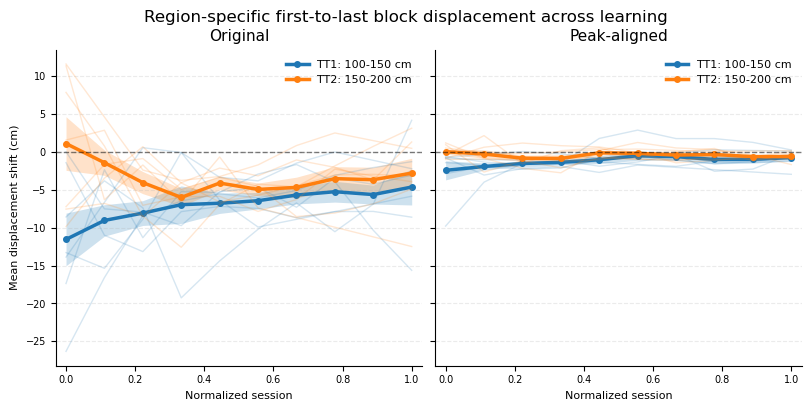

Saved PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/region_specific_displacement_learning_original_vs_peak_aligned.pdf


In [49]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

n_norm_sessions = 10
norm_x = np.linspace(0, 1, n_norm_sessions)

region_by_tt = {
    1: (100, 150),
    2: (150, 200)
}

colors = {
    1: "tab:blue",
    2: "tab:orange"
}

group_labels = {
    "original": "Original",
    "peak_aligned": "Peak-aligned"
}

# -------------------------------------------------------
# compute curves for both groups
# -------------------------------------------------------

curve_by_group_animal_tt = {}
interp_curve_by_group_tt = {}

for group in ["original", "peak_aligned"]:

    curve_by_group_animal_tt[group] = {}
    interp_curve_by_group_tt[group] = {}

    session_shift_matrix = session_shift_matrix_by_group_animal_tt[group]

    for trial_type in [1, 2]:

        region_cm = region_by_tt[trial_type]
        b0 = int(region_cm[0] / bin_size)
        b1 = int(region_cm[1] / bin_size)

        interp_curves = []
        animals_used = []

        for animal in animals:

            mat = session_shift_matrix[animal][trial_type]["matrix"]
            sessions = session_shift_matrix[animal][trial_type]["sessions"]

            if mat.size == 0 or mat.shape[0] < 2:
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                y = np.nanmean(mat[:, b0:b1], axis=1)

            valid = np.isfinite(y)

            if valid.sum() < 2:
                continue

            sess = sessions.astype(float)

            sess_norm = (
                sess - np.nanmin(sess)
            ) / (
                np.nanmax(sess) - np.nanmin(sess)
            )

            f = interp1d(
                sess_norm[valid],
                y[valid],
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate"
            )

            y_interp = f(norm_x)

            interp_curves.append(y_interp)
            animals_used.append(animal)

            curve_by_group_animal_tt[group][(animal, trial_type)] = {
                "sessions": sessions,
                "session_norm": sess_norm,
                "raw_curve": y,
                "interp_curve": y_interp,
                "region_cm": region_cm
            }

        interp_curves = np.asarray(interp_curves)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)

            mean_curve = np.nanmean(interp_curves, axis=0)

            if interp_curves.shape[0] > 1:
                sem_curve = (
                    np.nanstd(interp_curves, axis=0, ddof=1)
                    / np.sqrt(interp_curves.shape[0])
                )
            else:
                sem_curve = np.full_like(mean_curve, np.nan)

        interp_curve_by_group_tt[group][trial_type] = {
            "interp_curves": interp_curves,
            "mean": mean_curve,
            "sem": sem_curve,
            "animals_used": animals_used,
            "region_cm": region_cm,
            "norm_x": norm_x
        }


# -------------------------------------------------------
# plot both groups in 1 x 2 figure
# -------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.0, 3.8),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for ax, group in zip(axes, ["original", "peak_aligned"]):

    for trial_type in [1, 2]:

        d = interp_curve_by_group_tt[group][trial_type]

        curves = d["interp_curves"]
        mean_curve = d["mean"]
        sem_curve = d["sem"]
        region_cm = d["region_cm"]

        # individual animals
        for y in curves:
            ax.plot(
                norm_x,
                y,
                color=colors[trial_type],
                alpha=0.18,
                lw=1
            )

        # mean ± SEM
        ax.plot(
            norm_x,
            mean_curve,
            "-o",
            color=colors[trial_type],
            lw=2.5,
            ms=4,
            label=f"TT{trial_type}: {region_cm[0]}-{region_cm[1]} cm"
        )

        ax.fill_between(
            norm_x,
            mean_curve - sem_curve,
            mean_curve + sem_curve,
            color=colors[trial_type],
            alpha=0.22,
            linewidth=0
        )

    ax.axhline(
        0,
        color="k",
        ls="--",
        lw=1,
        alpha=0.5
    )

    ax.set_title(group_labels[group], fontsize=11)
    ax.set_xlabel("Normalized session")
    ax.set_xlim(-0.03, 1.03)
    ax.set_xticks(np.linspace(0, 1, 6))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("Mean displacement shift (cm)")

fig.suptitle(
    "Region-specific first-to-last block displacement across learning",
    fontsize=12,
    y=1.04
)

pdf_path = os.path.join(
    save_dir,
    "region_specific_displacement_learning_original_vs_peak_aligned.pdf"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

print(f"Saved PDF:\n{pdf_path}")

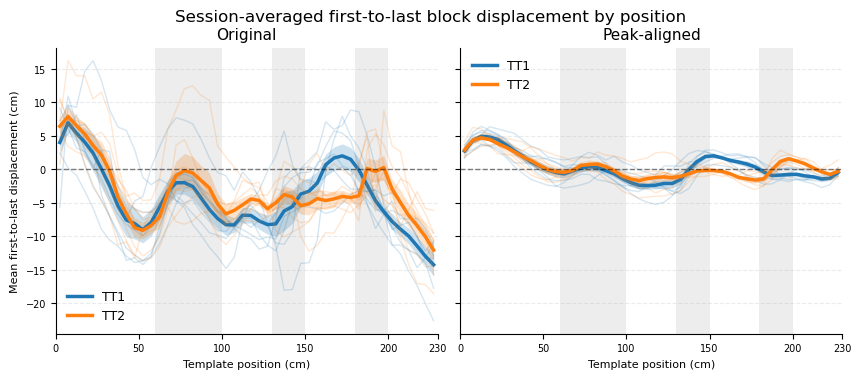

Saved PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/session_averaged_displacement_by_position_original_vs_peak_aligned_TT1_TT2.pdf


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

colors = {
    1: "tab:blue",
    2: "tab:orange"
}

group_labels = {
    "original": "Original",
    "peak_aligned": "Peak-aligned"
}


# -------------------------------------------------------
# average across sessions within each animal
# for both original and peak-aligned groups
# -------------------------------------------------------

animal_mean_vector_by_group_tt = {}

for group in ["original", "peak_aligned"]:

    animal_mean_vector_by_group_tt[group] = {}

    session_shift_matrix = session_shift_matrix_by_group_animal_tt[group]

    for trial_type in [1, 2]:

        animal_vectors = []
        animals_used = []

        for animal in animals:

            mat = session_shift_matrix[animal][trial_type]["matrix"]

            if mat.size == 0:
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                animal_vec = np.nanmean(mat, axis=0)

            if np.all(~np.isfinite(animal_vec)):
                continue

            animal_vectors.append(animal_vec)
            animals_used.append(animal)

        animal_vectors = np.asarray(animal_vectors)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)

            mean_vec = np.nanmean(animal_vectors, axis=0)

            if animal_vectors.shape[0] > 1:
                sem_vec = (
                    np.nanstd(animal_vectors, axis=0, ddof=1)
                    / np.sqrt(animal_vectors.shape[0])
                )
            else:
                sem_vec = np.full_like(mean_vec, np.nan)

        animal_mean_vector_by_group_tt[group][trial_type] = {
            "animal_vectors": animal_vectors,
            "mean": mean_vec,
            "sem": sem_vec,
            "animals_used": animals_used
        }


# -------------------------------------------------------
# plot both groups side by side
# -------------------------------------------------------

n_bins = animal_mean_vector_by_group_tt["original"][1]["mean"].shape[0]
x_cm = np.arange(n_bins) * bin_size + bin_size / 2

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.5, 3.5),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for ax, group in zip(axes, ["original", "peak_aligned"]):

    for trial_type in [1, 2]:

        d = animal_mean_vector_by_group_tt[group][trial_type]

        animal_vectors = d["animal_vectors"]
        mean_vec = d["mean"]
        sem_vec = d["sem"]

        # individual animals
        for y in animal_vectors:
            ax.plot(
                x_cm,
                y,
                color=colors[trial_type],
                alpha=0.18,
                lw=1
            )

        # mean ± SEM
        ax.plot(
            x_cm,
            mean_vec,
            color=colors[trial_type],
            lw=2.5,
            label=f"TT{trial_type}"
        )

        ax.fill_between(
            x_cm,
            mean_vec - sem_vec,
            mean_vec + sem_vec,
            color=colors[trial_type],
            alpha=0.22,
            linewidth=0
        )

    for a, b in [(60, 100), (130, 150), (180, 200)]:
        ax.axvspan(a, b, color="k", alpha=0.07, lw=0)

    ax.axhline(
        0,
        color="k",
        ls="--",
        lw=1,
        alpha=0.5
    )

    ax.set_xlim(0, track_len)
    ax.set_xticks([0, 50, 100, 150, 200, 230])

    ax.set_xlabel("Template position (cm)")
    ax.set_title(group_labels[group], fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel("Mean first-to-last displacement (cm)")

fig.suptitle(
    "Session-averaged first-to-last block displacement by position",
    fontsize=12,
    y=1.04
)

pdf_path = os.path.join(
    save_dir,
    "session_averaged_displacement_by_position_original_vs_peak_aligned_TT1_TT2.pdf"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

print(f"Saved PDF:\n{pdf_path}")

NameError: name 'session_shift_consecutive_by_group_animal_tt' is not defined